In [ ]:
import sys

# Step 1: Install gpjax (brings in numpyro, jax, etc.)
!{sys.executable} -m pip install -q gpjax

# Step 2: Patch numpyro's provenance.py for JAX 0.10.0 compatibility
# (xla_pmap_p was removed in JAX 0.10.0 but numpyro 0.20.1 still references it)
!sed -i 's/from jax.extend.core.primitives import call_p, closed_call_p, jit_p, xla_pmap_p/from jax.extend.core.primitives import call_p, closed_call_p, jit_p/' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

!sed -i 's/track_deps_rules\[xla_pmap_p\] = track_deps_call_rule//' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

print("Patch applied. Now restart your session, then import gpjax.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
Patch applied. Now restart your session, then import gpjax.


In [ ]:
import gpjax
print(gpjax.__version__)  # Works with modern JAX
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import arviz as az
import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

0.13.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpyro
import arviz as az

import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
#import jax
import jax.numpy as jnp
#import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict


In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random, jacfwd, jacrev
from jax import lax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.infer import Predictive

import gpjax as gpx
from gpjax import kernels, mean_functions

import optax

import numpy as np
import scipy

print("JAX version:", jax.__version__)
print("NumPyro version:", numpyro.__version__)
print("GPJax version:", gpx.__version__)
print("Default backend:", jax.default_backend())


JAX version: 0.10.0
NumPyro version: 0.20.1
GPJax version: 0.13.6
Default backend: cpu


## FORWARD MODELING

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=np.arctan((x-A+(0.5*m))/(D))-np.arctan((x-A-(0.5*m))/(D))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D)*f1)-(d*f2)+f3+f4
    g=2*G*rho*f #in miligal
    return g

In [ ]:
#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
def g_n_anomaly(N,x,A,m,D,d,rho):
    u=0
    for i in range(N):
        v=g_anomaly(x,A[i],m[i],D[i],d[i],rho[i])
        u=u+v

    return u

In [ ]:
#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
#Defining bottom depths of two layers by bd1 and bd2. Each element of bd1 representing bottom depth value of one prism. same for bd2 in meter
bd1=np.array([500,510,520,530,540,545,550,545,540,530,520,490,470,460,450,440,420,410,400,390,385,380,385,390,400,410,420,430,460,470])
bd2=np.array([800,790,780,770,760,755,750,755,760,770,780,810,830,840,850,860,880,890,900,910,915,920,915,910,900,890,880,870,850,830])
n= 30 #We are considering 30 prisms here
#surface value in meter
td=np.zeros(n)
for j in range(n):
    td[j]= 10**-6 # in meter (taking MSL as our observing surface i.e no undulation)
# Defining centre value of horizontal co-ordinate of each prism
#co=np.arange(-4500,4500,300)
co=np.linspace(-4350,4350,n)
# Defining width of each prism
wid=np.zeros(n)
for j in range(n):
    wid[j]= 300 # in meter
den1=np.zeros(n) #kg/m^3 density contrast for 1st layer
for i in range(n):
    den1[i]=-150
den2=np.zeros(n) #kg/m^3 density contrast for 1st layer
for i in range(n):
    den2[i]=-250
#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co[0]-(wid[0]*0.5)
xs[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs[i]=co[i-1]+(0.5*wid[i-1])
#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
zs1[0]=bd1[0]
zs1[n]=bd1[n-1]
for i in range(1,n):
    zs1[i]=bd1[i]
#Creating z2 co-ordinate values for 2nd layer for each prism
zs2=np.zeros(n+1)
zs2[0]=bd2[0]-5
zs2[n]=bd2[n-1]+5
for i in range(1,n):
    zs2[i]=(bd2[i-1]+bd2[i])*0.5
#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]
#Creating points for 1st layer
R1=np.zeros(((n+1),2))
for i in range(n+1):
    R1[i]=[xs[i],zs1[i]]

#Creating points for 1st layer
R1_1=np.zeros(((n+1),2))
for i in range(n):
    R1_1[i]=[xs[i+1],zs1[i]]
#Creating points for 2nd layer
R2=np.zeros(((n+1),2))
for i in range(n+1):
    R2[i]=[xs[i],zs2[i]]
#Creating points for 1st layer
R2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_1[i]=[xs[i+1],zs2[i]]

In [ ]:
#Defining "measure_func" function to calculate gravity anomaly for combined two layers in miligal with user defined station coordinates and above defined model parameters
def measure_func(x):
    return g_n_anomaly(n,x,co,wid,bd1,td,den1)+ g_n_anomaly(n,x,co,wid,bd2,bd1,den2)

In [ ]:

NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS)#Measurement points along the profile -5000 meter to 5000 meter
X_test=X
ground_truth=measure_func(X) #gravity anomaly with no noise added

In [ ]:
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
#Generate Gaussian Noise

gaussian_noise = np.random.normal(0, 0.3, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.1, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.05 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.05 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.01)**2))+(b*((X*0.01)**3))+c)

#Adding noise to the gravity anomaly data

y = measure_func(X) + random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)
y_f=interp1d(X,y,'linear')
y_true=y_f(X_test)#interpolating between noisy observations at finer fintervals

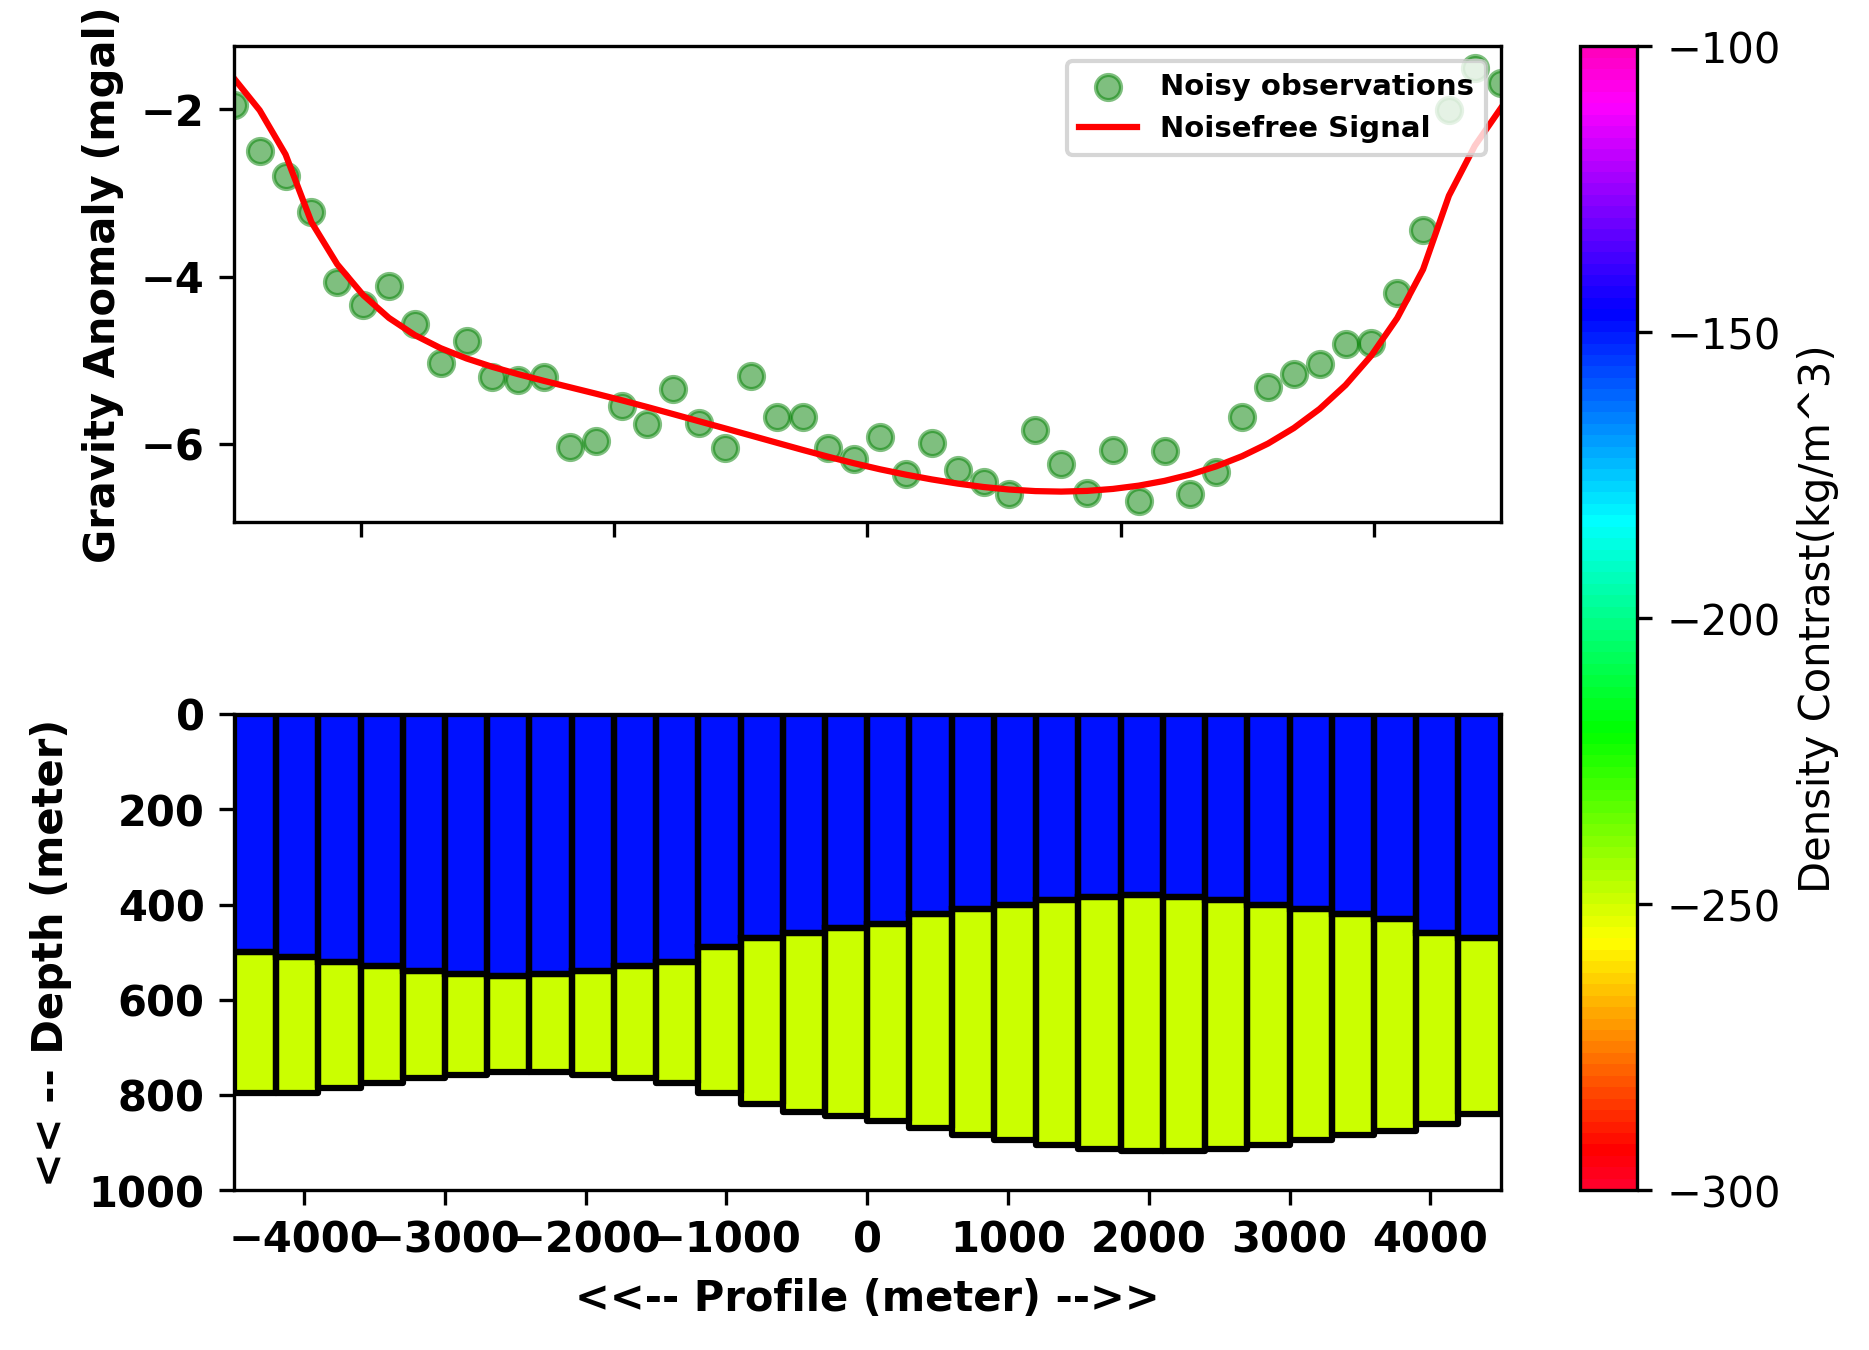

In [ ]:
from matplotlib.backend_bases import LocationEvent
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axs = plt.subplots(2)
fig.tight_layout(pad=2.5)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=-100 #maximum density in kg per m^3 in colorscale
minimum_V=-300 #minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')
for i in range(n):
    #choosing color from the colorscale acc to the density value of each prism of layer 1
    index_value_V1 = (den1[i]-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing color from the colorscale acc to the density value of each prism of layer 2
    index_value_V2 = (den2[i]-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #choosing color from the colorscale acc to the density value of each prism of layer 2
    #creating each prism using 4 corner co-ordinates
    coord1 = [R0[i], R0[i+1], R1_1[i], R1[i]]
    coord2 = [R1[i], R1_1[i], R2_1[i], R2[i]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1,ys1,'k')#plotting each prism of layer 1
    axs[1].plot(xs2,ys2,'k')#plotting each prism of layer 2
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling the prism of layer 1 acc to its density value
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling the prism of layer 2 acc to its density value

    axs[1].set_xlim(-4500,4500)
    axs[1].set_ylim(1000,0)
    axs[1].set_ylabel("<< -- Depth (meter)",fontsize=10,weight='bold')


coefficients = np.polyfit(X, y, 6)
polynomial = np.poly1d(coefficients)
# Generate line values
x_line = np.linspace(min(X), max(X), 100)
y_line = polynomial(x_line)


axs[0].scatter(X,y,alpha=0.5, c='g', marker='o', label="Noisy observations")#observed gravity anomaly at station points
#axs[0].plot(x_line, y_line, color='red', label=f'Best Fit Line')
axs[0].plot(X_test, ground_truth,  c='red', label="Noisefree Signal")#gravity anomaly at finer intervals without noise
axs[0].set_xlim(-5000,5000)
#axs[0].set_ylim(-5,0)
axs[1].set_ylim(1000,0)
axs[0].set_ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
axs[1].set_xlabel("<<-- Profile (meter) -->>",fontsize=10,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[1].get_xticklabels(), visible= True, weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True, weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True, weight='bold')
axs[0].set_xlim(-5000,5000)
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(loc='upper right', prop=legend_properties)
#axs[1].legend(['Forward Model'],prop=legend_properties)
#fig.suptitle("Forward Model",fontsize=12,weight='bold')
plt.show()

## **INVERSION**

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict

jax.config.update("jax_enable_x64", True)
X = jnp.array(X).reshape(-1, 1)  # now (50, 1)
y = jnp.array(y)                  # (50,)

#print(X.shape, y.shape)  # confirm: (50, 1) (50,)

In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan((x-A+(0.5*m))/D)-jnp.arctan((x-A-(0.5*m))/D)
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=(D*f1)-(d*f2)+f3+f4
    return 2*G*rho*f


In [ ]:
# CUSTOM MATERN KERNEL FOR v=3/2
def custom_Matern_kernel(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 3/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 3/2 formula
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1 + sqrt3 * D) * jnp.exp(-sqrt3 * D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

    # Example of a custom kernel prior for the above kernels
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """Custom priors for kernel hyperparameters."""
    import numpyro.distributions as dist
    k_scale = numpyro.sample("k_scale",dist.HalfNormal(1))
    k_length = numpyro.sample("k_length",dist.LogNormal(0,1))
    return {"k_length": k_length, "k_scale": k_scale}


In [ ]:
import random
depth1_lo_bounds = [random.uniform(float(bd1[i])-50,float(bd1[i])-40) for i in range(n)]
depth1_hi_bounds = [random.uniform(float(bd1[i])+40,float(bd1[i])+50) for i in range(n)]

depth2_lo_bounds = [random.uniform(float(bd2[i])-50,float(bd2[i])-40) for i in range(n)]
depth2_hi_bounds = [random.uniform(float(bd2[i])+40,float(bd2[i])+50) for i in range(n)]

#PRIORS with Comparatively good knolwdge of the geological area
def Bayes_Narrow_Inf_prior():
    params = {}
    params["density1"] = numpyro.sample(
            "density1",
              dist.Uniform(-170,-130))
    params["density2"] = numpyro.sample(
            "density2",
              dist.Uniform(-270,-230))
    for i in range(n):
        # ── Bottom depth prior ───────────────────────────────────
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}",
            dist.Uniform(depth1_lo_bounds[i], depth1_hi_bounds[i]))
        params[f"B_D2_{i+1}"] = numpyro.sample(
              f"B_D2_{i+1}",
              dist.Uniform(depth2_lo_bounds[i], depth2_hi_bounds[i]))

    return params
#PRIORS with very sparse knolwdge of the geological area
def Bayes_Sparse_Inf_prior():
    params = {}
    params["density1"] = numpyro.sample(
            "density1",
              dist.Uniform(-170,-130))
    params["density2"] = numpyro.sample(
            "density2",
              dist.Uniform(-270,-230))
    for i in range(n):
        # ── Bottom depth prior ───────────────────────────────────
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}",
            dist.Uniform(random.randint(500-(i*5)-100,500-(i*5)+10), random.randint(580-(i*5)-10,580-(i*5)+10)))
        params[f"B_D2_{i+1}"] = numpyro.sample(
              f"B_D2_{i+1}",
              dist.Uniform(random.randint(730+(i*5)-100,730+(i*5)+10), random.randint(830+(i*5)-10,830+(i*5)+10)))

    return params

## Defining Mean Function
def Bayes_Inf(x,params):
    u=0
    density1 = params["density1"] #density of each prism of layer 1 (model parameter to be inverted)
    density2 = params["density2"] #density of each prism of layer 1 (model parameter to be inverted)
    for i in range(n):
        B_D1 = params[f"B_D1_{i+1}"] #bottom depth of each prism of layer 1 (model parameter to be inverted)
        B_D2 = params[f"B_D2_{i+1}"] #bottom depth of each prism of layer 2 (model parameter to be inverted)
        v=g_ano(x,co[i],wid[i],B_D1,td[i],density1) #calculatiin of anomaly for layer 1
        w=g_ano(x,co[i],wid[i],B_D2,B_D1,density2) #calculatiin of anomaly for layer 2
        u=u+v+w #summed up anomaly
    return u

In [ ]:
def gp_predict(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    """
    Returns:
        y_pred     : (n_draws, N_test) - posterior means per draw
        y_sampled  : (n_draws, N_test) - posterior predictive samples
        pred_mean  : (N_test,)         - mean over posterior draws
        pred_std   : (N_test,)         - std over posterior draws
    """
    jitter = 1e-6

    # Ensure 2D
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means   = []
    all_samples = []

    for i in range(n_draws):
        # Extract posterior sample of kernel params
        k_scale   = samples["k_scale"][i]
        k_length  = samples["k_length"][i]
        noise_var = samples["noise_var"][i]

        # Build params dict for custom_Matern_kernel
        kernel_params = {
            "k_scale"  : k_scale,
            "k_length" : k_length
        }

        # Extract mean function params for this draw
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        # ── Use custom_Matern_kernel directly ──────────────────────
        # K(X_train, X_train)
        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)

        # K(X_test, X_train)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)

        # K(X_test, X_test)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])  # ensure PSD
        # ───────────────────────────────────────────────────────────

        # Posterior mean and covariance
        mean_train = Bayes_Inf(x_train_1d, mean_params_i)
        mean_test  = Bayes_Inf(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        # Posterior covariance
        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v
        cov_s += jitter * jnp.eye(X_test.shape[0])  # ensure PSD

        # Draw from posterior predictive
        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)

        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)  # (n_draws, N_test)
    y_pred    = jnp.stack(all_means)    # (n_draws, N_test)
    pred_mean = y_pred.mean(0)          # (N_test,)
    pred_std  = y_pred.std(0)           # (N_test,)

    return y_pred, y_sampled, pred_mean, pred_std

## STRUCTURED GP

Using Narrow Prior Range

In [ ]:
def gp_model1(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_Narrow_Inf_prior()
    mean_vec    = Bayes_Inf(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)



In [ ]:
# Run MCMC
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1 = MCMC(NUTS(gp_model1), num_warmup=20, num_samples=10)
mcmc1.run(rng_key, X, y)
samples1 = mcmc1.get_samples()

In [ ]:
#Storing the inverted results of narrow prior range

params1 = mcmc1.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths1 = np.zeros(n)
for i in range(n):
    top_inverted_depths1[i] = params1[f"B_D1_{i+1}"].mean()

bottom_inverted_depths1 = np.zeros(n)
for i in range(n):
    bottom_inverted_depths1[i] = params1[f"B_D2_{i+1}"].mean()

top_density1=params1["density1"].mean()
bottom_density1=params1["density2"].mean()

top_inverted_depths1_min=np.zeros(n)
top_inverted_depths1_max=np.zeros(n)
for i in range(n):
    top_inverted_depths1_min[i]=params1[f"B_D1_{i+1}"].min()
for i in range(n):
    top_inverted_depths1_max[i]=params1[f"B_D1_{i+1}"].max()

bottom_inverted_depths1_min=np.zeros(n)
bottom_inverted_depths1_max=np.zeros(n)
for i in range(n):
    bottom_inverted_depths1_min[i]=params1[f"B_D2_{i+1}"].min()
for i in range(n):
    bottom_inverted_depths1_max[i]=params1[f"B_D2_{i+1}"].max()
top_density1_min=params1["density1"].min()
top_density1_max=params1["density1"].max()
bottom_density1_min=params1["density2"].min()
bottom_density1_max=params1["density2"].max()

In [ ]:

B_D1_act_2=np.zeros(n)
B_D2_act_2=np.zeros(n)

for i in range(n):
    B_D1_act_2[i]=top_inverted_depths1[i]

for i in range(n):
    B_D2_act_2[i]=bottom_inverted_depths1[i]

density1_act=top_density1
density2_act=bottom_density1
#density2_act_2=np.zeros(n)
#for i in range(n):
    #density2_act_2[i]=params2[f'density2_{i+1}'].mean()

##Creating points from Inverted results##

#Creating x co-ordinates
xs_stra_2=np.zeros(n+1)
xs_stra_2[0]=co[0]-(wid[0]*0.5)
xs_stra_2[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs_stra_2[i]=co[i-1]+(0.5*wid[i-1])
#Creating bottom Co-ordinates for 1st layer
zs1_stra_2=np.zeros(n+1)
zs1_stra_2[0]=B_D1_act_2[0]-5
zs1_stra_2[n]=B_D1_act_2[n-1]+5
for i in range(1,n):
    zs1_stra_2[i]=(B_D1_act_2[i-1]+B_D1_act_2[i])*0.5
#Creating bottom Co-ordinates for second layer
zs2_stra_2=np.zeros(n+1)
zs2_stra_2[0]=B_D2_act_2[0]-5
zs2_stra_2[n]=B_D2_act_2[n-1]+5
for i in range(1,n):
    zs2_stra_2[i]=(B_D2_act_2[i-1]+B_D2_act_2[i])*0.5
#Creating points for ground layer
zs0_stra_2=np.zeros(n+1)
R0_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R0_stra_2[i]=[xs_stra_2[i],zs0_stra_2[i]]
#Creating bottom points for 1st layer
R1_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R1_stra_2[i]=[xs_stra_2[i],zs1_stra_2[i]]
R1_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R1_stra_2_1[i]=[xs_stra_2[i+1],zs1_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R2_stra_2[i]=[xs_stra_2[i],zs2_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_stra_2_1[i]=[xs_stra_2[i+1],zs2_stra_2[i]]

In [ ]:
# ── Step 1: Run gp_predict to get pred_mean and pred_std ────
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred, y_sampled, pred_mean, pred_std = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)

# Use sample statistics (same as your original Cell 27)
pred_mean = np.array(y_sampled.mean(0))
pred_std  = np.array(y_sampled.std(0))

X_test_np = np.array(X_test).flatten()
X_plot    = np.array(X).flatten()
y_plot    = np.array(y).flatten()

#PLOT THE INVERTED RESULTS FOR THE CASE HAVING GOOD PRIOR KNOWLEDGE
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1.3)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=-100#maximum density in kg per m^3 in colorscale
minimum_V=-300#minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')

for i in range(n):
    #choosing color from the colorscale acc to the inverted density value of each prism of layer 1
    index_value_V1 = (density1_act-minimum_V)/diff_V
    color_V1_act = cmap_V(index_value_V1)
    #choosing color from the colorscale acc to the inverted density value of each prism of layer 2
    index_value_V2 = (density2_act-minimum_V)/diff_V
    color_V2_act = cmap_V(index_value_V2)
    #creating each prism using 4 corner co-ordinates using inverted result
    coord1_stra = [R0_stra_2[i], R0_stra_2[i+1], R1_stra_2_1[i], R1_stra_2[i]]
    coord2_stra = [R1_stra_2[i], R1_stra_2_1[i], R2_stra_2_1[i], R2_stra_2[i]]
    coord1_stra.append(coord1_stra[0]) #repeat the first point to create a 'closed loop'
    coord2_stra.append(coord2_stra[0]) #repeat the first point to create a 'closed loop'
    xs1_stra, ys1_stra = zip(*coord1_stra) #create lists of x and y values
    xs2_stra, ys2_stra = zip(*coord2_stra) #create lists of x and y values
    #creating each prism using 4 corner co-ordinates using real values
    coord1 = [R0[i], R0[i+1], R1_1[i], R1[i]]
    coord2 = [R1[i], R1_1[i], R2_1[i], R2[i]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1_stra,ys1_stra,'k')#plotting each prism of layer 1 using inverted result
    axs[1].plot(xs1,ys1,'red',linestyle='dashed')#plotting each prism of layer 1 using real values
    axs[1].fill(xs1_stra, ys1_stra, facecolor=color_V1_act)#color filling each prism of layer 1 acc to its inverted density value
    axs[1].plot(xs2_stra,ys2_stra,'k')#plotting each prism of layer 2 using inverted result
    axs[1].fill(xs2_stra, ys2_stra, facecolor=color_V2_act)#color filling each prism of layer 2 acc to its inverted density value
    axs[1].plot(xs2,ys2,'red',linestyle='dashed')#plotting each prism of layer 2 using real values

    axs[1].set_ylabel("<< -- Depth (meter)",weight='bold')
    axs[1].set_xlim(-4650,4350)
    axs[1].set_ylim(1000,0)
    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['Inverted Boundary','Real Boundary'],prop=legend_properties)
    axs[1].set_xlabel("<< -- -- Profile (meter)-- -- >>",weight='bold')



# Panel 0 — Gravity anomaly fit
axs[0].scatter(X_plot, y_plot, marker='x', s=20, c='k',
               label="Observed Data", zorder=2)
axs[0].plot(X_test_np, pred_mean, '--', c='red', linewidth=2,
            label='Predicted Mean', zorder=1)
axs[0].fill_between(X_test_np,
                    pred_mean - pred_std,
                    pred_mean + pred_std,
                    color='r', alpha=0.2, label="Model Uncertainty")
axs[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight='bold')
axs[0].set_xlim(-5000, 5000)
axs[0].tick_params(labelbottom=False)
axs[0].legend(prop={'weight': 'bold', 'size': 7},loc='upper right')
#axs[0].set_title("Inversion with Structured GP", fontsize=11)
axs[0].grid(True, alpha=0.3)
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True,weight='bold')
plt.show()

Using Sparse Prior Range

In [ ]:
def gp_model2(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_Sparse_Inf_prior()
    mean_vec    = Bayes_Inf(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)



In [ ]:
# Run MCMC
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict1 = jax.random.split(rng_key)
mcmc2 = MCMC(NUTS(gp_model2), num_warmup=2000, num_samples=200)
mcmc2.run(rng_key, X, y)
samples2 = mcmc2.get_samples()

In [ ]:
#Storing the inverted results of SPARSE prior range

params2 = mcmc2.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths2 = np.zeros(n)
for i in range(n):
    top_inverted_depths2[i] = params2[f"B_D1_{i+1}"].mean()

bottom_inverted_depths2 = np.zeros(n)
for i in range(n):
    bottom_inverted_depths2[i] = params2[f"B_D2_{i+1}"].mean()

top_density2=params2["density1"].mean()
bottom_density2=params2["density2"].mean()

top_inverted_depths2_min=np.zeros(n)
top_inverted_depths2_max=np.zeros(n)
for i in range(n):
    top_inverted_depths2_min[i]=params2[f"B_D1_{i+1}"].min()
for i in range(n):
    top_inverted_depths2_max[i]=params2[f"B_D1_{i+1}"].max()

bottom_inverted_depths2_min=np.zeros(n)
bottom_inverted_depths2_max=np.zeros(n)
for i in range(n):
    bottom_inverted_depths2_min[i]=params2[f"B_D2_{i+1}"].min()
for i in range(n):
    bottom_inverted_depths2_max[i]=params2[f"B_D2_{i+1}"].max()
top_density2_min=params2["density1"].min()
top_density2_max=params2["density1"].max()
bottom_density2_min=params2["density2"].min()
bottom_density2_max=params2["density2"].max()

In [ ]:
#Storing the inverted results

B_D1_act_2=np.zeros(n)
B_D2_act_2=np.zeros(n)

for i in range(n):
    B_D1_act_2[i]=top_inverted_depths2[i]

for i in range(n):
    B_D2_act_2[i]=bottom_inverted_depths2[i]

density1_act=top_density2
density2_act=bottom_density2

##Creating points from Inverted results##

#Creating x co-ordinates
xs_stra_2=np.zeros(n+1)
xs_stra_2[0]=co[0]-(wid[0]*0.5)
xs_stra_2[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs_stra_2[i]=co[i-1]+(0.5*wid[i-1])
#Creating bottom Co-ordinates for 1st layer
zs1_stra_2=np.zeros(n+1)
zs1_stra_2[0]=B_D1_act_2[0]-5
zs1_stra_2[n]=B_D1_act_2[n-1]+5
for i in range(1,n):
    zs1_stra_2[i]=(B_D1_act_2[i-1]+B_D1_act_2[i])*0.5
#Creating bottom Co-ordinates for second layer
zs2_stra_2=np.zeros(n+1)
zs2_stra_2[0]=B_D2_act_2[0]-5
zs2_stra_2[n]=B_D2_act_2[n-1]+5
for i in range(1,n):
    zs2_stra_2[i]=(B_D2_act_2[i-1]+B_D2_act_2[i])*0.5
#Creating points for ground layer
zs0_stra_2=np.zeros(n+1)
R0_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R0_stra_2[i]=[xs_stra_2[i],zs0_stra_2[i]]
#Creating bottom points for 1st layer
R1_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R1_stra_2[i]=[xs_stra_2[i],zs1_stra_2[i]]
R1_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R1_stra_2_1[i]=[xs_stra_2[i+1],zs1_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R2_stra_2[i]=[xs_stra_2[i],zs2_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_stra_2_1[i]=[xs_stra_2[i+1],zs2_stra_2[i]]

In [ ]:
# ── Step 1: Run gp_predict to get pred_mean and pred_std ────
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred, y_sampled, pred_mean, pred_std = gp_predict(
    rng_key_predict, X, y, X_test, samples2, n_samples=50
)

# Use sample statistics (same as your original Cell 27)
pred_mean = np.array(y_sampled.mean(0))
pred_std  = np.array(y_sampled.std(0))

X_test_np = np.array(X_test).flatten()
X_plot    = np.array(X).flatten()
y_plot    = np.array(y).flatten()

#PLOT THE INVERTED RESULTS FOR THE CASE HAVING GOOD PRIOR KNOWLEDGE
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1.3)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=-100#maximum density in kg per m^3 in colorscale
minimum_V=-300#minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')

for i in range(n):
    #choosing color from the colorscale acc to the inverted density value of each prism of layer 1
    index_value_V1 = (density1_act-minimum_V)/diff_V
    color_V1_act = cmap_V(index_value_V1)
    #choosing color from the colorscale acc to the inverted density value of each prism of layer 2
    index_value_V2 = (density2_act-minimum_V)/diff_V
    color_V2_act = cmap_V(index_value_V2)
    #creating each prism using 4 corner co-ordinates using inverted result
    coord1_stra = [R0_stra_2[i], R0_stra_2[i+1], R1_stra_2_1[i], R1_stra_2[i]]
    coord2_stra = [R1_stra_2[i], R1_stra_2_1[i], R2_stra_2_1[i], R2_stra_2[i]]
    coord1_stra.append(coord1_stra[0]) #repeat the first point to create a 'closed loop'
    coord2_stra.append(coord2_stra[0]) #repeat the first point to create a 'closed loop'
    xs1_stra, ys1_stra = zip(*coord1_stra) #create lists of x and y values
    xs2_stra, ys2_stra = zip(*coord2_stra) #create lists of x and y values
    #creating each prism using 4 corner co-ordinates using real values
    coord1 = [R0[i], R0[i+1], R1_1[i], R1[i]]
    coord2 = [R1[i], R1[i+1], R2_1[i], R2[i]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1_stra,ys1_stra,'k')#plotting each prism of layer 1 using inverted result
    axs[1].plot(xs1,ys1,'red',linestyle='dashed')#plotting each prism of layer 1 using real values
    axs[1].fill(xs1_stra, ys1_stra, facecolor=color_V1_act)#color filling each prism of layer 1 acc to its inverted density value
    axs[1].plot(xs2_stra,ys2_stra,'k')#plotting each prism of layer 2 using inverted result
    axs[1].fill(xs2_stra, ys2_stra, facecolor=color_V2_act)#color filling each prism of layer 2 acc to its inverted density value
    axs[1].plot(xs2,ys2,'red',linestyle='dashed')#plotting each prism of layer 2 using real values

    axs[1].set_ylabel("<< -- Depth (meter)",weight='bold')
    axs[1].set_xlim(-45000,4500)
    axs[1].set_ylim(1000,0)
    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['Inverted Boundary','Real Boundary'],prop=legend_properties)
    axs[1].set_xlabel("<< -- -- Profile (meter)-- -- >>",weight='bold')



# Panel 0 — Gravity anomaly fit
axs[0].scatter(X_plot, y_plot, marker='x', s=20, c='k',
               label="Observed Data", zorder=2)
axs[0].plot(X_test_np, pred_mean, '--', c='red', linewidth=2,
            label='Predicted Mean', zorder=1)
axs[0].fill_between(X_test_np,
                    pred_mean - pred_std,
                    pred_mean + pred_std,
                    color='r', alpha=0.2, label="Model Uncertainty")
axs[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight='bold')
axs[0].set_xlim(-5000, 5000)
axs[0].tick_params(labelbottom=False)
axs[0].legend(prop={'weight': 'bold', 'size': 7},loc='upper right')
#axs[0].set_title("Inversion with Structured GP", fontsize=11)
axs[0].grid(True, alpha=0.3)
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True,weight='bold')
plt.show()

## Compare Plot Fig 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ─────────────────────────────────────────────────────────────────────────────
# TRUE MODEL PARAMETERS (from your forward model)
# bd1, bd2   : true bottom depths of Layer 1 and Layer 2   shape (n,)
# den1, den2 : true density contrasts                      shape (n,) → scalar
# xs         : prism edge x-coordinates                    shape (n+1,)
# co         : prism centre x-coordinates                  shape (n,)
# n          : 30 prisms
# ─────────────────────────────────────────────────────────────────────────────
true_rho1 = den1[0]   # -150  kg/m³  (uniform across prisms)
true_rho2 = den2[0]   # -250  kg/m³

prism_idx = np.arange(1, n + 1)   # 1 … 30

# ─────────────────────────────────────────────────────────────────────────────
# COLOUR PALETTE  (consistent across every figure)
# ─────────────────────────────────────────────────────────────────────────────
C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Run gp_predict to get pred_mean and pred_std ────
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred1, y_sampled1, pred_mean1, pred_std1 = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)
######
y_pred2, y_sampled2, pred_mean2, pred_std2 = gp_predict(
    rng_key_predict1, X, y, X_test, samples2, n_samples=50
)
#####
pred_mean1 = np.array(y_sampled1.mean(0))
pred_std1  = np.array(y_sampled1.std(0))
pred_mean2 = np.array(y_sampled2.mean(0))
pred_std2  = np.array(y_sampled2.std(0))

X_test_np = np.array(X_test).flatten()
X_plot    = np.array(X).flatten()
y_plot    = np.array(y).flatten()

# =============================================================================
# FIGURE 1 — Side-by-side subsurface cross-sections
# =============================================================================
def plot_cross_section(ax, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None,Gravity_anomaly=None, vmin=-280, vmax=-120):
    cmap = plt.get_cmap("gist_rainbow", 512)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # ── Top row: Gravity anomaly ──────────────────────────────
    ax[0].scatter(X_plot, y_plot, alpha=0.5, c='green', marker='o',s=10,
               label="Observed Data", zorder=2)

    if Gravity_anomaly is not None:
        ax[0].plot(X, Gravity_anomaly, c='red', linewidth=2,label='Noisefree Signal', zorder=1)
    # Only plot the mean and std if predicted_mean is provided
    if predicted_mean is not None:
        ax[0].plot(X_test_np, predicted_mean, '--', c='red', linewidth=2,
                    label='Predicted Mean', zorder=1)

        # Only process std if it's provided along with the mean
        if predicted_std is not None:
            if np.all(predicted_std==0):
               pass
            else:
              ax[0].fill_between(X_test_np,
                                predicted_mean - predicted_std,
                                predicted_mean + predicted_std,
                                color='r', alpha=0.2, label="Model Uncertainty")

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly(mGal)", weight="bold")
    ax[0].set_title(title, weight="bold")
    ax[0].legend(fontsize=8)

    # ── Bottom row: Cross-section model ──────────────────────
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]

        # Layer 1
        z_top1 = 0.0
        z_bot1 = INV_DEP_TOP[i]
        col1   = cmap(norm(INV_DEN_TOP))
        ax[1].fill([xl, xr, xr, xl],
                   [z_top1, z_top1, z_bot1, z_bot1], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [z_top1, z_top1, z_bot1, z_bot1, z_top1],
                   color="grey", lw=0.3)

        # Layer 2
        z_top2 = INV_DEP_TOP[i]
        z_bot2 = INV_DEP_BOTTOM[i]
        col2   = cmap(norm(INV_DEN_BOTTOM))
        ax[1].fill([xl, xr, xr, xl],
                   [z_top2, z_top2, z_bot2, z_bot2], color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [z_top2, z_top2, z_bot2, z_bot2, z_top2],
                   color="grey", lw=0.3)

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", weight="bold")
    ax[1].set_ylabel("Depth (m)", weight="bold")
    plt.setp(ax[0].get_xticklabels(), visible= False)
    plt.setp(ax[0].get_yticklabels(), visible= True,weight='bold')
    plt.setp(ax[1].get_xticklabels(), visible= True,weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible= True,weight='bold')




vmin, vmax = -280, -120
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig1, axs1 = plt.subplots(2, 3, figsize=(18, 6), dpi=300)
fig1.suptitle("Forward and Inverted Models  (Narrow vs Sparse)",
              fontsize=13, weight="bold")
# Forward Model Call
plot_cross_section(axs1[:, 0], bd1, den1[0], bd2, den2[0], "Forward Model",Gravity_anomaly=measure_func(X))

# Narrow Prior Call
plot_cross_section(axs1[:, 1], top_inverted_depths1, top_density1, bottom_inverted_depths1, bottom_density1, "Inverted Model (Narrow Prior)",
                   predicted_mean=pred_mean1, predicted_std=pred_std1)

# Sparse Prior Call
plot_cross_section(axs1[:, 2], top_inverted_depths2, top_density2, bottom_inverted_depths2, bottom_density2, "Inverted Model (Sparse Prior)",
                   predicted_mean=pred_mean2, predicted_std=pred_std2)

# ... (rest of your colorbar code remains exactly the same)

# ── Reserve space on the right for the colorbar ───────────────────────────
plt.subplots_adjust(right=0.88)   # shrink subplots to 88% of figure width

# ── Add a dedicated axes for the colorbar [left, bottom, width, height] ──
cbar_ax = fig1.add_axes([0.90, 0.10, 0.015, 0.80])   # tall, narrow strip on the right

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig1.colorbar(sm, cax=cbar_ax, orientation="vertical",
                     ticks=np.linspace(vmin, vmax, 5))
cbar.set_label("Density Contrast (kg/m³)")

plt.show()

# =============================================================================
# FIGURE 2 — Per-prism depth comparison with min–max uncertainty band
# =============================================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(16, 10), dpi=300, sharex=True)
fig2.suptitle("Inverted Depths — Mean ± Full Range  (Narrow vs Sparse)",
              fontsize=13, weight="bold")

depth_pairs = [
    (axs2[0],
     "Layer 1 Bottom Depth",
     top_inverted_depths1, top_inverted_depths1_min, top_inverted_depths1_max,
     top_inverted_depths2, top_inverted_depths2_min, top_inverted_depths2_max,
     bd1),
    (axs2[1],
     "Layer 2 Bottom Depth",
     bottom_inverted_depths1, bottom_inverted_depths1_min, bottom_inverted_depths1_max,
     bottom_inverted_depths2, bottom_inverted_depths2_min, bottom_inverted_depths2_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    # Narrow prior band + mean
    ax.fill_between(prism_idx, n_min, n_max,
                    color=C_NARROW, alpha=ALPHA_BAND,
                    label="Narrow range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2,
            label="Narrow mean")

    # Sparse prior band + mean
    ax.fill_between(prism_idx, s_min, s_max,
                    color=C_SPARSE, alpha=ALPHA_BAND,
                    label="Sparse range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--",
            label="Sparse mean")

    # True depth
    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.",
            label="True depth")

    ax.set_ylabel("Depth (m)", weight="bold")
    ax.set_title(label, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axs2[1].set_xlabel("Prism Index", weight="bold")
axs2[1].set_xticks(prism_idx)
plt.tight_layout()
#plt.savefig("fig2_depth_comparison.png", dpi=150, bbox_inches="tight")
plt.setp(axs2[1].get_xticklabels(), visible= True,weight='bold')

plt.setp(axs2[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs2[0].get_yticklabels(), visible= True,weight='bold')
plt.show()


# =============================================================================
# FIGURE 3 — Depth error & uncertainty width per prism (bar charts)
# =============================================================================
bar_w  = 0.38
offset = bar_w / 2 + 0.04

fig3, axs3 = plt.subplots(1, 2, figsize=(9, 3), dpi=300, sharex=True)
fig3.suptitle("Depth Mismatch(Inverted − True) — Narrow vs Sparse",
              fontsize=11, weight="bold")

depth_specs = [
    ("Layer1 Depth Error",
     top_inverted_depths1 - bd1,
     top_inverted_depths2 - bd1,
     axs3[0]),
    ("Layer2 Depth Error",
     bottom_inverted_depths1 - bd2,
     bottom_inverted_depths2 - bd2,
     axs3[1]),

]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w,
           color=C_NARROW, alpha=0.85, label="Narrow")
    ax.bar(prism_idx + offset, s_vals, width=bar_w,
           color=C_SPARSE,  alpha=0.85, label="Sparse")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, weight="bold")
    ax.set_ylabel("Depth Error (m)", weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    # Show only every 10th tick from existing data
    ticks = ax.get_xticks()
    ax.set_xticks(ticks[::10])
    ax.legend(fontsize=8)

for ax in axs3:
    ax.set_xlabel("Prism Index", weight="bold")
    ax.set_xticks(prism_idx)

plt.tight_layout()
#plt.savefig("fig3_error_and_width.png", dpi=150, bbox_inches="tight")
plt.setp(axs3[1].get_xticklabels(), visible= True,weight='bold')
plt.setp(axs3[1].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs3[0].get_yticklabels(), visible= True,weight='bold')
plt.setp(axs3[0].get_xticklabels(), visible= True,weight='bold')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ─────────────────────────────────────────────────────────────────────────────
# TRUE MODEL PARAMETERS (from your forward model)
# bd1, bd2   : true bottom depths of Layer 1 and Layer 2  shape (n,)
# den1, den2 : true density contrasts                       shape (n,) -> scalar
# xs         : prism edge x-coordinates                    shape (n+1,)
# co         : prism centre x-coordinates                  shape (n,)
# n          : 30 prisms
# ─────────────────────────────────────────────────────────────────────────────
true_rho1 = den1[0]   # -150  kg/m³  (uniform across prisms)
true_rho2 = den2[0]   # -250  kg/m³

prism_idx = np.arange(1, n + 1)   # 1 … 30

# ─────────────────────────────────────────────────────────────────────────────
# COLOUR PALETTE  (consistent across every figure)
# ─────────────────────────────────────────────────────────────────────────────
C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Run gp_predict to get pred_mean and pred_std ────
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred1, y_sampled1, pred_mean1, pred_std1 = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)
######
y_pred2, y_sampled2, pred_mean2, pred_std2 = gp_predict(
    rng_key_predict1, X, y, X_test, samples2, n_samples=50
)
#####
pred_mean1 = np.array(y_sampled1.mean(0))
pred_std1  = np.array(y_sampled1.std(0))
pred_mean2 = np.array(y_sampled2.mean(0))
pred_std2  = np.array(y_sampled2.std(0))

X_test_np = np.array(X_test).flatten()
X_plot    = np.array(X).flatten()
y_plot    = np.array(y).flatten()

# =============================================================================
# FIGURE 1 — Side-by-side subsurface cross-sections
# =============================================================================
def plot_cross_section(ax, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None,Gravity_anomaly=None, vmin=-280, vmax=-120):
    cmap = plt.get_cmap("gist_rainbow", 512)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # ── Top row: Gravity anomaly ──────────────────────────────
    ax[0].scatter(X_plot, y_plot, alpha=0.5, c='green', marker='o',s=10,
               label="Observed Data", zorder=2)

    if Gravity_anomaly is not None:
        ax[0].plot(X, Gravity_anomaly, c='red', linewidth=2,label='Noisefree Signal', zorder=1)
    # Only plot the mean and std if predicted_mean is provided
    if predicted_mean is not None:
        ax[0].plot(X_test_np, predicted_mean, '--', c='red', linewidth=2,
                    label='Predicted Mean', zorder=1)

        # Only process std if it's provided along with the mean
        if predicted_std is not None:
            if np.all(predicted_std==0):
               pass
            else:
              ax[0].fill_between(X_test_np,
                                predicted_mean - predicted_std,
                                predicted_mean + predicted_std,
                                color='r', alpha=0.2, label="Model Uncertainty")

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight="bold")
    ax[0].set_title(title, fontsize=14, weight="bold")
    ax[0].legend(fontsize=8,loc="upper right")

    # ── Bottom row: Cross-section model ──────────────────────
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]

        # Layer 1
        z_top1 = 0.0
        z_bot1 = INV_DEP_TOP[i]
        col1   = cmap(norm(INV_DEN_TOP))
        ax[1].fill([xl, xr, xr, xl],
                   [z_top1, z_top1, z_bot1, z_bot1], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [z_top1, z_top1, z_bot1, z_bot1, z_top1],
                   color="grey", lw=0.3)

        # Layer 2
        z_top2 = INV_DEP_TOP[i]
        z_bot2 = INV_DEP_BOTTOM[i]
        col2   = cmap(norm(INV_DEN_BOTTOM))
        ax[1].fill([xl, xr, xr, xl],
                   [z_top2, z_top2, z_bot2, z_bot2], color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [z_top2, z_top2, z_bot2, z_bot2, z_top2],
                   color="grey", lw=0.3)

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", fontsize=12, weight="bold")
    ax[1].set_ylabel("Depth (m)", fontsize=10, weight="bold")
    plt.setp(ax[0].get_xticklabels(), visible= False)
    plt.setp(ax[0].get_yticklabels(), visible= True, weight='bold')
    plt.setp(ax[1].get_xticklabels(), visible= True, weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible= True, weight='bold')

vmin, vmax = -280, -120
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Reduced figsize width for a paper, maintaining aspect ratio
fig1, axs1 = plt.subplots(2, 3, figsize=(18, 6), dpi=300)
fig1.suptitle("Forward and Inverted Models (Narrow vs Sparse)",
              fontsize=21, weight="bold")

# Forward Model Call
plot_cross_section(axs1[:, 0], bd1, den1[0], bd2, den2[0], "Forward Model",Gravity_anomaly=measure_func(X))

# Narrow Prior Call
plot_cross_section(axs1[:, 1], top_inverted_depths1, top_density1, bottom_inverted_depths1, bottom_density1, "Inverted Model (Narrow Prior)",
                   predicted_mean=pred_mean1, predicted_std=pred_std1)

# Sparse Prior Call
plot_cross_section(axs1[:, 2], top_inverted_depths2, top_density2, bottom_inverted_depths2, bottom_density2, "Inverted Model (Sparse Prior)",
                   predicted_mean=pred_mean2, predicted_std=pred_std2)

# ── Reserve space on the right for the colorbar ───────────────────────────
plt.subplots_adjust(right=0.88)   # shrink subplots to 88% of figure width

# ── Add a dedicated axes for the colorbar [left, bottom, width, height] ──
cbar_ax = fig1.add_axes([0.90, 0.10, 0.015, 0.80])   # tall, narrow strip on the right

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig1.colorbar(sm, cax=cbar_ax, orientation="vertical",
                     ticks=np.linspace(vmin, vmax, 5))
cbar.set_label("Density Contrast (kg/m³)", fontsize=12)

plt.show()

# =============================================================================
# FIGURE 2 — Per-prism depth comparison with min–max uncertainty band
# =============================================================================
# Adjusted height to fit well on a standard page
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8), dpi=300, sharex=True)
fig2.suptitle("Inverted Depths — Mean ± Std Range (Narrow vs Sparse)",
              fontsize=16, weight="bold")

depth_pairs = [
    (axs2[0],
     "Layer 1",
     top_inverted_depths1, top_inverted_depths1_min, top_inverted_depths1_max,
     top_inverted_depths2, top_inverted_depths2_min, top_inverted_depths2_max,
     bd1),
    (axs2[1],
     "Layer 2",
     bottom_inverted_depths1, bottom_inverted_depths1_min, bottom_inverted_depths1_max,
     bottom_inverted_depths2, bottom_inverted_depths2_min, bottom_inverted_depths2_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    # Narrow prior band + mean
    ax.fill_between(prism_idx, n_min, n_max,
                    color=C_NARROW, alpha=ALPHA_BAND,
                    label="Narrow range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2,
            label="Narrow mean")

    # Sparse prior band + mean
    ax.fill_between(prism_idx, s_min, s_max,
                    color=C_SPARSE, alpha=ALPHA_BAND,
                    label="Sparse range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--",
            label="Sparse mean")

    # True depth
    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.",
            label="True depth")

    ax.set_ylabel("Depth (m)", fontsize=10, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8,loc="upper right")

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx)
plt.tight_layout()
#plt.savefig("fig2_depth_comparison.png", dpi=150, bbox_inches="tight")
plt.setp(axs2[1].get_xticklabels(), visible= True, weight='bold')

plt.setp(axs2[1].get_yticklabels(), visible= True, weight='bold')
plt.setp(axs2[0].get_yticklabels(), visible= True, weight='bold')
plt.show()

# =============================================================================
# FIGURE 3 — Depth error & uncertainty width per prism (bar charts)
# =============================================================================
bar_w  = 0.38
offset = bar_w / 2 + 0.04

fig3, axs3 = plt.subplots(1, 2, figsize=(10, 4), dpi=300, sharex=True)
fig3.suptitle("Depth Mismatch (Inverted − True) — Narrow vs Sparse",
              fontsize=16, weight="bold")

depth_specs = [
    ("Layer 1",
     top_inverted_depths1 - bd1,
     top_inverted_depths2 - bd1,
     axs3[0]),
    ("Layer 2",
     bottom_inverted_depths1 - bd2,
     bottom_inverted_depths2 - bd2,
     axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w,
           color=C_NARROW, alpha=0.85, label="Narrow")
    ax.bar(prism_idx + offset, s_vals, width=bar_w,
           color=C_SPARSE,  alpha=0.85, label="Sparse")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=10, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold") # Moved here
    ax.grid(True, axis="y", alpha=0.3)

    # ── Updated Tick Logic ──
    # Set the ticks using your prism_idx array, taking every 7th element
    ax.set_xticks(prism_idx[::7])

    ax.legend(fontsize=8,loc="upper right")

plt.tight_layout()

# Standardize appearance for publication
for ax in axs3:
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

plt.show()

In [ ]:
# =============================================================================
# MERGED FIGURE — All three figures combined, original sizes preserved
# =============================================================================

# Total height = 6 + 8 + 4 = 18 inches, width = 18 (widest figure)
fig_merged = plt.figure(figsize=(18, 16), dpi=300)

# Create 3 subfigures stacked vertically with height ratios matching original sizes
# Fig1=6in, Fig2=8in, Fig3=4in → ratios 6:8:4 = 3:4:2
subfigs = fig_merged.subfigures(3, 1, height_ratios=[6, 8, 4], hspace=0.08)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 1 — Forward and Inverted Models (Narrow vs Sparse)
# ─────────────────────────────────────────────────────────────────────────────
subfigs[0].suptitle("Forward and Inverted Models (Narrow vs Sparse)",
                     fontsize=21, weight="bold")

axs1 = subfigs[0].subplots(2, 3)

subfigs[0].subplots_adjust(right=0.80,wspace=0.35,hspace=0.08,top=0.80)
#subfigs[0].subplots_adjust(top=0.84)  # leave headroom for the suptitle
# Shrink subplots further left to make room (was 0.84)
#subfigs[0].subplots_adjust(right=0.80, wspace=0.35)


# Forward Model
plot_cross_section(axs1[:, 0], bd1, den1[0], bd2, den2[0],
                   "Forward Model", Gravity_anomaly=measure_func(X))


# Narrow Prior
plot_cross_section(axs1[:, 1], top_inverted_depths1, top_density1,
                   bottom_inverted_depths1, bottom_density1,
                   "Inverted Model (Narrow Prior)",
                   predicted_mean=pred_mean1, predicted_std=pred_std1)
# Sparse Prior
plot_cross_section(axs1[:, 2], top_inverted_depths2, top_density2,
                   bottom_inverted_depths2, bottom_density2,
                   "Inverted Model (Sparse Prior)",
                   predicted_mean=pred_mean2, predicted_std=pred_std2)

# Colorbar for subfig 1
#cbar_ax1 = subfigs[0].add_axes([0.90, 0.10, 0.015, 0.80])
#cbar_ax1 = subfigs[0].add_axes([0.86, 0.10, 0.013, 0.80])
# Place colorbar in the freed-up space
cbar_ax1 = subfigs[0].add_axes([0.83, 0.10, 0.013, 0.80])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar1 = subfigs[0].colorbar(sm, cax=cbar_ax1, orientation="vertical",
                              ticks=np.linspace(vmin, vmax, 5))
cbar1.set_label("Density Contrast (kg/m³)", fontsize=12)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 2 — Per-prism depth comparison
# ─────────────────────────────────────────────────────────────────────────────
subfigs[1].suptitle("Inverted Depths — Mean ± Std Range (Narrow vs Sparse)",
                     fontsize=16, weight="bold")

axs2 = subfigs[1].subplots(2, 1, sharex=True)

depth_pairs = [
    (axs2[0], "Layer 1",
     top_inverted_depths1, top_inverted_depths1_min, top_inverted_depths1_max,
     top_inverted_depths2, top_inverted_depths2_min, top_inverted_depths2_max,
     bd1),
    (axs2[1], "Layer 2",
     bottom_inverted_depths1, bottom_inverted_depths1_min, bottom_inverted_depths1_max,
     bottom_inverted_depths2, bottom_inverted_depths2_min, bottom_inverted_depths2_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    ax.fill_between(prism_idx, n_min, n_max, color=C_NARROW, alpha=ALPHA_BAND, label="Narrow range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2, label="Narrow mean")
    ax.fill_between(prism_idx, s_min, s_max, color=C_SPARSE, alpha=ALPHA_BAND, label="Sparse range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--", label="Sparse mean")
    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.", label="True depth")
    ax.set_ylabel("Depth (m)", fontsize=12, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx)
plt.setp(axs2[1].get_xticklabels(), visible=True, weight='bold')
subfigs[1].subplots_adjust(hspace=0.35)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 3 — Depth error bar charts
# ─────────────────────────────────────────────────────────────────────────────

# ── Replace the subfigs[2].suptitle line with this ──
subfigs[2].suptitle("Depth Mismatch (Inverted − True) — Narrow vs Sparse",
                     fontsize=16, weight="bold", y=1.02)  # push title above subplots


axs3 = subfigs[2].subplots(1, 2)
# ── Add this after subfigs[2].subplots(...) ──
subfigs[2].subplots_adjust(top=0.82)  # leave headroom for the suptitle

bar_w  = 0.38
offset = bar_w / 2 + 0.04

depth_specs = [
    ("Layer 1", top_inverted_depths1 - bd1,    top_inverted_depths2 - bd1,    axs3[0]),
    ("Layer 2", bottom_inverted_depths1 - bd2, bottom_inverted_depths2 - bd2, axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w, color=C_NARROW, alpha=0.85, label="Narrow")
    ax.bar(prism_idx + offset, s_vals, width=bar_w, color=C_SPARSE,  alpha=0.85, label="Sparse")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=12, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(prism_idx[::7])
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# SAVE & SHOW
# ─────────────────────────────────────────────────────────────────────────────
#plt.savefig("merged_all_figures.png", dpi=300, bbox_inches="tight")
plt.show()
#print("Saved → merged_all_figures.png")

## Active Learning

In [ ]:
#Choosing random values for initial points within a range(geologically & geophysically justified)
import random
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
PARAMS={}
PARAMS["density1"] = random.uniform(top_density1_min,top_density1_max)
PARAMS["density2"] = random.uniform(bottom_density1_min,bottom_density1_max)
for i in range(n):
    PARAMS[f"B_D1_{i+1}"] = random.uniform(top_inverted_depths1_min[i],top_inverted_depths1_max[i])
    PARAMS[f"B_D2_{i+1}"] = random.uniform(bottom_inverted_depths1_min[i],bottom_inverted_depths1_max[i])

In [ ]:
#Inversion of Narrow prior range

import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", True)

# ── Initial setup (same as before) ──────────────────────────
SEED = 42
np.random.seed(SEED)
N_POLY_COEFFS=4
# Starting observations
Xo = np.array(X).flatten().copy()
yo = np.array(y).flatten().copy()

X_test_AL = np.linspace(-5000, 5000, 100)   # candidate points for active learning

# ── Uncertainty Exploration acquisition function ─────────────
def uncertainty_exploration(pred_std):
    """Returns index of point with highest posterior std."""
    return np.argmax(pred_std)


# ── Forward model at a single point (for active learning) ────
def forward_at_point(x_new, params_mean):
    """
    Evaluate the forward model at a single new x location
    using the posterior mean parameters.
    Used to generate a 'measurement' at the suggested point.
    """
    x_arr = jnp.array([x_new])
    return float(Bayes_Inf(x_arr, params_mean)[0])


# ── Active Learning Loop ─────────────────────────────────────
n_exploration_steps = 5   # same as your original

rng_key = jax.random.PRNGKey(SEED)
rng_key, rng_key_predict = jax.random.split(rng_key)

for step in range(n_exploration_steps):
    print(f"\n{'='*50}")
    print(f"Exploration step {step + 1}")
    print(f"{'='*50}")
    print(f"Current number of observations: {len(Xo)}")

    # ── Step 1: Fit GP model on current observations ─────────
    X_jnp = jnp.array(Xo).reshape(-1, 1)
    y_jnp = jnp.array(yo)

    mcmc_al = MCMC(
        NUTS(gp_model1),
        num_warmup=2000,
        num_samples=50,
        num_chains=1,
        progress_bar=True
    )
    mcmc_al.run(rng_key, X_jnp, y_jnp)
    samples_al = mcmc_al.get_samples()

    # Print summary
    print(f"\nPosterior summary — step {step + 1}:")
    inverted_depths1_al = np.array([samples_al[f"B_D1_{i+1}"].mean() for i in range(n)])
    inverted_depths2_al = np.array([samples_al[f"B_D2_{i+1}"].mean() for i in range(n)])
    density1_al = [samples_al["density1"].mean()]
    density2_al = [samples_al["density2"].mean()]

    print(f"  Mean depth range: [{inverted_depths1_al.min():.1f}, {inverted_depths1_al.max():.1f}] m")
    print(f"  Mean depth range: [{inverted_depths2_al.min():.1f}, {inverted_depths2_al.max():.1f}] m")

    # ── Step 2: Predict over candidate points ─────────────────
    X_test_jnp = jnp.array(X_test_AL).reshape(-1, 1)

    _, y_sampled_al, pred_mean_al, pred_std_al = gp_predict(
        rng_key_predict, X_jnp, y_jnp, X_test_jnp, samples_al, n_samples=75
    )
    pred_mean_al = np.array(y_sampled_al.mean(0))
    pred_std_al  = np.array(y_sampled_al.std(0))

    # ── Step 3: Uncertainty Exploration — find next point ─────
    next_idx   = uncertainty_exploration(pred_std_al)
    next_point = X_test_AL[next_idx]
    print(f"\nNext suggested point: x = {next_point:.2f} m")
    print(f"  Uncertainty at that point: {pred_std_al[next_idx]:.4f} mGal")

    # ── Step 4: Generate 'measurement' at new point ───────────
    # Reconstruct posterior mean params for forward evaluation
    params_mean = {}
    for i in range(n):
        params_mean[f"B_D1_{i+1}"] = jnp.array(samples_al[f"B_D1_{i+1}"].mean())
        params_mean[f"B_D2_{i+1}"] = jnp.array(samples_al[f"B_D2_{i+1}"].mean())
        params_mean["density1"] = jnp.array(samples_al["density1"].mean())
        params_mean["density2"] = jnp.array(samples_al["density2"].mean())

    # Evaluate forward model at new point + add noise (same noise model as original)
    y_new_clean = forward_at_point(next_point, params_mean)

    # Add same noise as original observations

    y_new = y_new_clean

    print(f"  Measured value: {y_new:.4f} mGal")

    # ── Step 5: Append new observation ───────────────────────
    Xo = np.append(Xo, next_point)
    yo = np.append(yo, y_new)

    # Update rng keys for next iteration
    rng_key, rng_key_predict = jax.random.split(rng_key)

print(f"\nActive learning complete.")
print(f"Total observations: {len(Xo)} (started with {len(np.array(X).flatten())})")


# ── Final full MCMC on all observations ──────────────────────
print("\nRunning final MCMC on all observations...")

X_final = jnp.array(Xo).reshape(-1, 1)
y_final = jnp.array(yo)

mcmc3 = MCMC(
    NUTS(gp_model1),
    num_warmup=2000,
    num_samples=50,
    num_chains=1,
    progress_bar=True
)
mcmc3.run(rng_key, X_final, y_final)
samples3 = mcmc3.get_samples()


# ── Plot active learning progression ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.dpi = 300

original_X = np.array(X).flatten()
added_X    = Xo[len(original_X):]   # the points added during active learning

ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)
ax.scatter(added_X, yo[len(original_X):],
           marker='*', s=100, c='red', label='Active learning points', zorder=3)

# Plot final prediction
X_test_final_jnp = jnp.array(X_test_AL).reshape(-1, 1)
_, y_samp_f, pred_mean_f, pred_std_f = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp, samples3, n_samples=50
)
pred_mean_f = np.array(y_samp_f.mean(0))
pred_std_f  = np.array(y_samp_f.std(0))

ax.plot(X_test_AL, pred_mean_f, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL,
                pred_mean_f - pred_std_f,
                pred_mean_f + pred_std_f,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
ax.set_title("Active Learning — Observation Points", fontsize=11)
ax.set_xlim(-5000, 5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("active_learning_progression.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Storing the inverted results of Narrow prior range

params3 = mcmc3.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths3 = np.zeros(n)
for i in range(n):
    top_inverted_depths3[i] = params3[f"B_D1_{i+1}"].mean()

bottom_inverted_depths3 = np.zeros(n)
for i in range(n):
    bottom_inverted_depths3[i] = params3[f"B_D2_{i+1}"].mean()

top_density3=params3["density1"].mean()
bottom_density3=params3["density2"].mean()

top_inverted_depths3_min=np.zeros(n)
top_inverted_depths3_max=np.zeros(n)
for i in range(n):
    top_inverted_depths3_min[i]=params3[f"B_D1_{i+1}"].min()
for i in range(n):
    top_inverted_depths3_max[i]=params3[f"B_D1_{i+1}"].max()

bottom_inverted_depths3_min=np.zeros(n)
bottom_inverted_depths3_max=np.zeros(n)
for i in range(n):
    bottom_inverted_depths3_min[i]=params3[f"B_D2_{i+1}"].min()
for i in range(n):
    bottom_inverted_depths3_max[i]=params3[f"B_D2_{i+1}"].max()
top_density3_min=params3["density1"].min()
top_density3_max=params3["density1"].max()
bottom_density3_min=params3["density2"].min()
bottom_density3_max=params3["density2"].max()

In [ ]:
#Storing the inverted results

B_D1_act_2=np.zeros(n)
B_D2_act_2=np.zeros(n)

for i in range(n):
    B_D1_act_2[i]=top_inverted_depths3[i]

for i in range(n):
    B_D2_act_2[i]=bottom_inverted_depths3[i]

density1_act=top_density3
density2_act=bottom_density3

##Creating points from Inverted results##

#Creating x co-ordinates
xs_stra_2=np.zeros(n+1)
xs_stra_2[0]=co[0]-(wid[0]*0.5)
xs_stra_2[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs_stra_2[i]=co[i-1]+(0.5*wid[i-1])
#Creating bottom Co-ordinates for 1st layer
zs1_stra_2=np.zeros(n+1)
zs1_stra_2[0]=B_D1_act_2[0]-5
zs1_stra_2[n]=B_D1_act_2[n-1]+5
for i in range(1,n):
    zs1_stra_2[i]=(B_D1_act_2[i-1]+B_D1_act_2[i])*0.5
#Creating bottom Co-ordinates for second layer
zs2_stra_2=np.zeros(n+1)
zs2_stra_2[0]=B_D2_act_2[0]-5
zs2_stra_2[n]=B_D2_act_2[n-1]+5
for i in range(1,n):
    zs2_stra_2[i]=(B_D2_act_2[i-1]+B_D2_act_2[i])*0.5
#Creating points for ground layer
zs0_stra_2=np.zeros(n+1)
R0_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R0_stra_2[i]=[xs_stra_2[i],zs0_stra_2[i]]
#Creating bottom points for 1st layer
R1_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R1_stra_2[i]=[xs_stra_2[i],zs1_stra_2[i]]
R1_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R1_stra_2_1[i]=[xs_stra_2[i+1],zs1_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R2_stra_2[i]=[xs_stra_2[i],zs2_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_stra_2_1[i]=[xs_stra_2[i+1],zs2_stra_2[i]]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Plot active learning progression ─────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(10, 10)) # Use plt.subplots to get fig and axs array
fig.dpi = 300

# First subplot (Gravity Anomaly)
ax = axs[0] # Assign axs[0] to ax for consistency with existing code

original_X = np.array(X).flatten()
added_X1    = Xo[len(original_X):]   # the points added during active learning
added_y1    = yo[len(original_X):]
X_test_AL1 = X_test_AL
X_final1 = X_final
y_final1 = y_final
y_samp_f1 = y_samp_f
ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)

# Plot final prediction
X_test_final_jnp1 = jnp.array(X_test_AL1).reshape(-1, 1)
_, y_samp_f1, pred_mean_f1, pred_std_f1 = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp1, samples3, n_samples=50
)
pred_mean_f1 = np.array(y_samp_f1.mean(0))
pred_std_f1  = np.array(y_samp_f1.std(0))

# Plot the points discovered during the active learning loop with a color gradient
sc = ax.scatter(added_X1, added_y1,
           c=np.arange(1, len(added_X1) + 1), cmap='viridis',
           marker='*', s=100, label='Active learning points', zorder=3,
           edgecolors='k') # Added edgecolors for better visibility
cbar = fig.colorbar(sc, ax=ax, label="Exploration step") # Link colorbar to scatter plot
cbar.set_ticks(np.arange(1, len(added_X1) + 1))
#plot mean and std
ax.plot(X_test_AL1, pred_mean_f1, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL1,
                pred_mean_f1 - pred_std_f1,
                pred_mean_f1 + pred_std_f1,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
#ax.set_title("Active Learning — Observation Points", fontsize=11)
ax.set_xlim(-5000,5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)
plt.setp(ax.get_yticklabels(), weight='bold') # Set y-tick label weight for axs[0]
plt.tight_layout()

# Second subplot (Geological Model)
plt.sca(axs[1]) # Set current axes to axs[1]

cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=-100 #maximum density in kg per m^3 in colorscale
minimum_V=-300 #minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs[1],label='Density Contrast(kg/m^3)') # Pass axs[1] directly

# Get scalar density values from lists
density1_scalar = top_density3
density2_scalar = bottom_density3

# Calculate colors once (these are constant for all prisms in this context)


# Reconstruct true R points using n1 data for consistent plotting comparison


#creating prisms using 4 corner co-ordinates using inverted results
for i in range(n):
    index_value_V1 = (density1_scalar - minimum_V) / diff_V
    color_V1_act = cmap_V(index_value_V1)
    index_value_V2 = (density2_scalar - minimum_V) / diff_V
    color_V2_act = cmap_V(index_value_V2)
    # Inverted boundaries
    coord1_stra = [R0_stra_2[i], R0_stra_2[i+1], R1_stra_2_1[i], R1_stra_2[i]]
    coord2_stra = [R1_stra_2[i], R1_stra_2_1[i], R2_stra_2[i+1], R2_stra_2[i]]
    coord1_stra.append(coord1_stra[0]) #repeat the first point to create a 'closed loop'
    coord2_stra.append(coord2_stra[0])
    xs1_stra, ys1_stra = zip(*coord1_stra) #create lists of x and y values
    xs2_stra, ys2_stra = zip(*coord2_stra) #create lists of x and y values

    # True boundaries (now also based on n1 interpolated points)
    coord1_true = [R0[i], R0[i+1], R1[i+1], R1[i]]
    coord2_true = [R1[i], R1[i+1], R2[i+1], R2[i]]
    coord1_true.append(coord1_true[0]) #repeat the first point to create a 'closed loop'
    coord2_true.append(coord2_true[0])
    xs1_true, ys1_true = zip(*coord1_true) #create lists of x and y values
    xs2_true, ys2_true = zip(*coord2_true) #create lists of x and y values

    axs[1].plot(xs1_stra,ys1_stra,'k',linewidth=0.8) #plotting each prism of layer 1 using inverted result
    axs[1].plot(xs1_true,ys1_true,'red',linestyle='dashed',linewidth=0.5) #plotting each prism of layer 1 using real values
    axs[1].fill(xs1_stra, ys1_stra, facecolor=color_V1_act) #color filling each prism of layer 1 acc to its inverted density value

    axs[1].plot(xs2_stra,ys2_stra,'k',linewidth=0.8) #plotting each prism of layer 2 using inverted result
    axs[1].fill(xs2_stra, ys2_stra, facecolor=color_V2_act) #color filling each prism of layer 2 acc to its inverted density value
    axs[1].plot(xs2_true,ys2_true,'red',linestyle='dashed',linewidth=0.5) #plotting each prism of layer 2 using real values

axs[1].set_xlim(-4500,4500) # Use axs[1]
axs[1].set_ylim(1000,0) # Use axs[1]
axs[1].set_ylabel("<< -- Depth (meter)",weight='bold') # Use axs[1]
legend_properties = {'weight':'bold','size':'7'}
axs[1].legend(['Inverted Boundary','Real Boundary'],prop=legend_properties)
axs[1].set_xlabel("<< -- -- Profile (meter)-- -- >>",weight='bold') # Use axs[1]
plt.setp(axs[1].get_xticklabels(), weight='bold') # Make x-tick labels bold for axs[1]
plt.setp(axs[1].get_yticklabels(), weight='bold') # Make y-tick labels bold for axs[1]

plt.show()

In [ ]:
#Inversion of Sparse prior range
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", True)

# ── Initial setup (same as before) ──────────────────────────
SEED = 42
np.random.seed(SEED)
N_POLY_COEFFS=4
# Starting observations
Xo = np.array(X).flatten().copy()
yo = np.array(y).flatten().copy()

X_test_AL = np.linspace(-5000, 5000, 100)   # candidate points for active learning

# ── Uncertainty Exploration acquisition function ─────────────
def uncertainty_exploration(pred_std):
    """Returns index of point with highest posterior std."""
    return np.argmax(pred_std)


# ── Forward model at a single point (for active learning) ────
def forward_at_point(x_new, params_mean):
    """
    Evaluate the forward model at a single new x location
    using the posterior mean parameters.
    Used to generate a 'measurement' at the suggested point.
    """
    x_arr = jnp.array([x_new])
    return float(Bayes_Inf(x_arr, params_mean)[0])


# ── Active Learning Loop ─────────────────────────────────────
n_exploration_steps = 5   # same as your original

rng_key = jax.random.PRNGKey(SEED)
rng_key, rng_key_predict = jax.random.split(rng_key)

for step in range(n_exploration_steps):
    print(f"\n{'='*50}")
    print(f"Exploration step {step + 1}")
    print(f"{'='*50}")
    print(f"Current number of observations: {len(Xo)}")

    # ── Step 1: Fit GP model on current observations ─────────
    X_jnp = jnp.array(Xo).reshape(-1, 1)
    y_jnp = jnp.array(yo)

    mcmc_al = MCMC(
        NUTS(gp_model2),
        num_warmup=2000,
        num_samples=50,
        num_chains=1,
        progress_bar=True
    )
    mcmc_al.run(rng_key, X_jnp, y_jnp)
    samples_al = mcmc_al.get_samples()

    # Print summary
    print(f"\nPosterior summary — step {step + 1}:")
    inverted_depths1_al = np.array([samples_al[f"B_D1_{i+1}"].mean() for i in range(n)])
    inverted_depths2_al = np.array([samples_al[f"B_D2_{i+1}"].mean() for i in range(n)])
    density1_al = [samples_al["density1"].mean()]
    density2_al = [samples_al["density2"].mean()]

    print(f"  Mean depth range: [{inverted_depths1_al.min():.1f}, {inverted_depths1_al.max():.1f}] m")
    print(f"  Mean depth range: [{inverted_depths2_al.min():.1f}, {inverted_depths2_al.max():.1f}] m")

    # ── Step 2: Predict over candidate points ─────────────────
    X_test_jnp = jnp.array(X_test_AL).reshape(-1, 1)

    _, y_sampled_al, pred_mean_al, pred_std_al = gp_predict(
        rng_key_predict, X_jnp, y_jnp, X_test_jnp, samples_al, n_samples=75
    )
    pred_mean_al = np.array(y_sampled_al.mean(0))
    pred_std_al  = np.array(y_sampled_al.std(0))

    # ── Step 3: Uncertainty Exploration — find next point ─────
    next_idx   = uncertainty_exploration(pred_std_al)
    next_point = X_test_AL[next_idx]
    print(f"\nNext suggested point: x = {next_point:.2f} m")
    print(f"  Uncertainty at that point: {pred_std_al[next_idx]:.4f} mGal")

    # ── Step 4: Generate 'measurement' at new point ───────────
    # Reconstruct posterior mean params for forward evaluation
    params_mean = {}
    for i in range(n):
        params_mean[f"B_D1_{i+1}"] = jnp.array(samples_al[f"B_D1_{i+1}"].mean())
        params_mean[f"B_D2_{i+1}"] = jnp.array(samples_al[f"B_D2_{i+1}"].mean())
        params_mean["density1"] = jnp.array(samples_al["density1"].mean())
        params_mean["density2"] = jnp.array(samples_al["density2"].mean())

    # Evaluate forward model at new point + add noise (same noise model as original)
    y_new_clean = forward_at_point(next_point, params_mean)

    # Add same noise as original observations

    y_new = y_new_clean

    print(f"  Measured value: {y_new:.4f} mGal")

    # ── Step 5: Append new observation ───────────────────────
    Xo = np.append(Xo, next_point)
    yo = np.append(yo, y_new)

    # Update rng keys for next iteration
    rng_key, rng_key_predict = jax.random.split(rng_key)

print(f"\nActive learning complete.")
print(f"Total observations: {len(Xo)} (started with {len(np.array(X).flatten())})")


# ── Final full MCMC on all observations ──────────────────────
print("\nRunning final MCMC on all observations...")

X_final = jnp.array(Xo).reshape(-1, 1)
y_final = jnp.array(yo)

mcmc4 = MCMC(
    NUTS(gp_model2),
    num_warmup=2000,
    num_samples=50,
    num_chains=1,
    progress_bar=True
)
mcmc4.run(rng_key, X_final, y_final)
samples4 = mcmc3.get_samples()


# ── Plot active learning progression ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.dpi = 300

original_X = np.array(X).flatten()
added_X    = Xo[len(original_X):]   # the points added during active learning

ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)
ax.scatter(added_X, yo[len(original_X):],
           marker='*', s=100, c='red', label='Active learning points', zorder=3)

# Plot final prediction
X_test_final_jnp = jnp.array(X_test_AL).reshape(-1, 1)
_, y_samp_f, pred_mean_f, pred_std_f = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp, samples3, n_samples=50
)
pred_mean_f = np.array(y_samp_f.mean(0))
pred_std_f  = np.array(y_samp_f.std(0))

ax.plot(X_test_AL, pred_mean_f, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL,
                pred_mean_f - pred_std_f,
                pred_mean_f + pred_std_f,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
ax.set_title("Active Learning — Observation Points", fontsize=11)
ax.set_xlim(-5000, 5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("active_learning_progression.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Storing the inverted results of Sparse prior range

params4 = mcmc4.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths4 = np.zeros(n)
for i in range(n):
    top_inverted_depths4[i] = params4[f"B_D1_{i+1}"].mean()

bottom_inverted_depths4 = np.zeros(n)
for i in range(n):
    bottom_inverted_depths4[i] = params4[f"B_D2_{i+1}"].mean()

top_density4=params4["density1"].mean()
bottom_density4=params4["density2"].mean()

top_inverted_depths4_min=np.zeros(n)
top_inverted_depths4_max=np.zeros(n)
for i in range(n):
    top_inverted_depths4_min[i]=params4[f"B_D1_{i+1}"].min()
for i in range(n):
    top_inverted_depths4_max[i]=params4[f"B_D1_{i+1}"].max()

bottom_inverted_depths4_min=np.zeros(n)
bottom_inverted_depths4_max=np.zeros(n)
for i in range(n):
    bottom_inverted_depths4_min[i]=params4[f"B_D2_{i+1}"].min()
for i in range(n):
    bottom_inverted_depths4_max[i]=params4[f"B_D2_{i+1}"].max()
top_density4_min=params4["density1"].min()
top_density4_max=params4["density1"].max()
bottom_density4_min=params4["density2"].min()
bottom_density4_max=params4["density2"].max()

In [ ]:
#Storing the inverted results

B_D1_act_2=np.zeros(n)
B_D2_act_2=np.zeros(n)

for i in range(n):
    B_D1_act_2[i]=top_inverted_depths4[i]

for i in range(n):
    B_D2_act_2[i]=bottom_inverted_depths4[i]

density1_act=top_density4
density2_act=bottom_density4

##Creating points from Inverted results##

#Creating x co-ordinates
xs_stra_2=np.zeros(n+1)
xs_stra_2[0]=co[0]-(wid[0]*0.5)
xs_stra_2[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs_stra_2[i]=co[i-1]+(0.5*wid[i-1])
#Creating bottom Co-ordinates for 1st layer
zs1_stra_2=np.zeros(n+1)
zs1_stra_2[0]=B_D1_act_2[0]-5
zs1_stra_2[n]=B_D1_act_2[n-1]+5
for i in range(1,n):
    zs1_stra_2[i]=(B_D1_act_2[i-1]+B_D1_act_2[i])*0.5
#Creating bottom Co-ordinates for second layer
zs2_stra_2=np.zeros(n+1)
zs2_stra_2[0]=B_D2_act_2[0]-5
zs2_stra_2[n]=B_D2_act_2[n-1]+5
for i in range(1,n):
    zs2_stra_2[i]=(B_D2_act_2[i-1]+B_D2_act_2[i])*0.5
#Creating points for ground layer
zs0_stra_2=np.zeros(n+1)
R0_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R0_stra_2[i]=[xs_stra_2[i],zs0_stra_2[i]]
#Creating bottom points for 1st layer
R1_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R1_stra_2[i]=[xs_stra_2[i],zs1_stra_2[i]]
R1_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R1_stra_2_1[i]=[xs_stra_2[i+1],zs1_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R2_stra_2[i]=[xs_stra_2[i],zs2_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_stra_2_1[i]=[xs_stra_2[i+1],zs2_stra_2[i]]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Plot active learning progression ─────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(10, 10)) # Use plt.subplots to get fig and axs array
fig.dpi = 300

# First subplot (Gravity Anomaly)
ax = axs[0] # Assign axs[0] to ax for consistency with existing code

original_X = np.array(X).flatten()
added_X2    = Xo[len(original_X):]   # the points added during active learning
added_y2    = yo[len(original_X):]
X_test_AL2 = X_test_AL
X_final2 = X_final
y_final2 = y_final
y_samp_f2 = y_samp_f

ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)

# Plot final prediction
X_test_final_jnp2 = jnp.array(X_test_AL2).reshape(-1, 1)
_, y_samp_f2, pred_mean_f2, pred_std_f2 = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp2, samples4, n_samples=50
)
pred_mean_f2 = np.array(y_samp_f2.mean(0))
pred_std_f2  = np.array(y_samp_f2.std(0))

# Plot the points discovered during the active learning loop with a color gradient
sc = ax.scatter(added_X2, added_y2,
           c=np.arange(1, len(added_X2) + 1), cmap='viridis',
           marker='*', s=100, label='Active learning points', zorder=3,
           edgecolors='k') # Added edgecolors for better visibility
cbar = fig.colorbar(sc, ax=ax, label="Exploration step") # Link colorbar to scatter plot
cbar.set_ticks(np.arange(1, len(added_X2) + 1))
#plot mean and std
ax.plot(X_test_AL2, pred_mean_f2, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL2,
                pred_mean_f2 - pred_std_f2,
                pred_mean_f2 + pred_std_f2,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
#ax.set_title("Active Learning — Observation Points", fontsize=11)
ax.set_xlim(-5000,5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)
plt.setp(ax.get_yticklabels(), weight='bold') # Set y-tick label weight for axs[0]
plt.tight_layout()

# Second subplot (Geological Model)
plt.sca(axs[1]) # Set current axes to axs[1]

cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=-100 #maximum density in kg per m^3 in colorscale
minimum_V=-300 #minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs[1],label='Density Contrast(kg/m^3)') # Pass axs[1] directly

# Get scalar density values from lists
density1_scalar = top_density4
density2_scalar = bottom_density4

# Calculate colors once (these are constant for all prisms in this context)


# Reconstruct true R points using n1 data for consistent plotting comparison


#creating prisms using 4 corner co-ordinates using inverted results
for i in range(n):
    index_value_V1 = (density1_scalar - minimum_V) / diff_V
    color_V1_act = cmap_V(index_value_V1)
    index_value_V2 = (density2_scalar - minimum_V) / diff_V
    color_V2_act = cmap_V(index_value_V2)
    # Inverted boundaries
    coord1_stra = [R0_stra_2[i], R0_stra_2[i+1], R1_stra_2_1[i], R1_stra_2[i]]
    coord2_stra = [R1_stra_2[i], R1_stra_2_1[i], R2_stra_2_1[i], R2_stra_2[i]]
    coord1_stra.append(coord1_stra[0]) #repeat the first point to create a 'closed loop'
    coord2_stra.append(coord2_stra[0])
    xs1_stra, ys1_stra = zip(*coord1_stra) #create lists of x and y values
    xs2_stra, ys2_stra = zip(*coord2_stra) #create lists of x and y values

    # True boundaries (now also based on n1 interpolated points)
    coord1_true = [R0[i], R0[i+1], R1[i+1], R1[i]]
    coord2_true = [R1[i], R1[i+1], R2[i+1], R2[i]]
    coord1_true.append(coord1_true[0]) #repeat the first point to create a 'closed loop'
    coord2_true.append(coord2_true[0])
    xs1_true, ys1_true = zip(*coord1_true) #create lists of x and y values
    xs2_true, ys2_true = zip(*coord2_true) #create lists of x and y values

    axs[1].plot(xs1_stra,ys1_stra,'k',linewidth=0.8) #plotting each prism of layer 1 using inverted result
    axs[1].plot(xs1_true,ys1_true,'red',linestyle='dashed',linewidth=0.5) #plotting each prism of layer 1 using real values
    axs[1].fill(xs1_stra, ys1_stra, facecolor=color_V1_act) #color filling each prism of layer 1 acc to its inverted density value

    axs[1].plot(xs2_stra,ys2_stra,'k',linewidth=0.8) #plotting each prism of layer 2 using inverted result
    axs[1].fill(xs2_stra, ys2_stra, facecolor=color_V2_act) #color filling each prism of layer 2 acc to its inverted density value
    axs[1].plot(xs2_true,ys2_true,'red',linestyle='dashed',linewidth=0.5) #plotting each prism of layer 2 using real values

axs[1].set_xlim(-4500,4500) # Use axs[1]
axs[1].set_ylim(1000,0) # Use axs[1]
axs[1].set_ylabel("<< -- Depth (meter)",weight='bold') # Use axs[1]
legend_properties = {'weight':'bold','size':'7'}
axs[1].legend(['Inverted Boundary','Real Boundary'],prop=legend_properties)
axs[1].set_xlabel("<< -- -- Profile (meter)-- -- >>",weight='bold') # Use axs[1]
plt.setp(axs[1].get_xticklabels(), weight='bold') # Make x-tick labels bold for axs[1]
plt.setp(axs[1].get_yticklabels(), weight='bold') # Make y-tick labels bold for axs[1]

plt.show()

## COMPARE PLOT (FIGURE 6)

In [ ]:
########## COMPARE PLOT 6 #########

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

true_rho1 = den1[0]
true_rho2 = den2[0]
prism_idx = np.arange(1, n + 1)

C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

vmin, vmax = -280, -120
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# =============================================================================
# FIGURE 1 — Side-by-side subsurface cross-sections
# =============================================================================
def plot_cross_section(ax, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None, Gravity_anomaly=None,
                       addedX=None, addedy=None, Xtest_AL=None, vmin=-280, vmax=-120):

    sc = None  # default — returned even if no active learning points

    # ── Top row: Gravity anomaly ──────────────────────────────────────────────
    ax[0].scatter(original_X, np.array(y).flatten(),
                  alpha=0.5, c='green', marker='o', s=10,
                  label="Observed Data", zorder=2)

    if Gravity_anomaly is not None:
        ax[0].plot(X, Gravity_anomaly, c='red', linewidth=2,
                   label='Noisefree Signal', zorder=1)

    if addedX is not None and addedy is not None:
        sc = ax[0].scatter(addedX, addedy,
                           c=np.arange(1, len(addedX) + 1), cmap='viridis',
                           marker='*', s=100, label='Active learning points',
                           zorder=3, edgecolors='k')

    if predicted_mean is not None:
        ax[0].plot(Xtest_AL, predicted_mean, '--', c='red', linewidth=2,
                   label='Predicted mean')
        if predicted_std is not None:
            if not np.all(predicted_std == 0):
                ax[0].fill_between(Xtest_AL,
                                   predicted_mean - predicted_std,
                                   predicted_mean + predicted_std,
                                   color='r', alpha=0.2, label='Model uncertainty')

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight="bold")
    ax[0].set_title(title, fontsize=14, weight="bold")
    ax[0].legend(fontsize=8, loc="upper right")
    plt.setp(ax[0].get_xticklabels(), visible=False)
    plt.setp(ax[0].get_yticklabels(), visible=True, weight='bold')

    # ── Bottom row: Cross-section model ──────────────────────────────────────
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]

        # Layer 1
        col1 = cmap(norm(INV_DEN_TOP))
        ax[1].fill([xl, xr, xr, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i]], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i], 0.0],
                   color="grey", lw=0.3)

        # Layer 2
        col2 = cmap(norm(INV_DEN_BOTTOM))
        ax[1].fill([xl, xr, xr, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i]],
                   color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i], INV_DEP_TOP[i]],
                   color="grey", lw=0.3)

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", fontsize=12, weight="bold")
    ax[1].set_ylabel("Depth (m)", fontsize=10, weight="bold")
    plt.setp(ax[1].get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible=True, weight='bold')

    return sc


# ── Build figure ─────────────────────────────────────────────────────────────
fig1, axs1 = plt.subplots(2, 3, figsize=(18, 6), dpi=300)
fig1.suptitle("Forward and Inverted Models (Narrow vs Sparse)",
              fontsize=21, weight="bold")

plot_cross_section(axs1[:, 0], bd1, den1[0], bd2, den2[0],
                   "Forward Model", Gravity_anomaly=measure_func(X))

sc1 = plot_cross_section(axs1[:, 1], top_inverted_depths3, top_density3,
                         bottom_inverted_depths3, bottom_density3,
                         "Inverted Model (Narrow Prior)",
                         predicted_mean=pred_mean_f1, predicted_std=pred_std_f1,
                         addedX=added_X1, addedy=added_y1, Xtest_AL=X_test_AL1)

sc2 = plot_cross_section(axs1[:, 2], top_inverted_depths4, top_density4,
                         bottom_inverted_depths4, bottom_density4,
                         "Inverted Model (Sparse Prior)",
                         predicted_mean=pred_mean_f2, predicted_std=pred_std_f2,
                         addedX=added_X2, addedy=added_y2, Xtest_AL=X_test_AL2)

# ── Shrink subplots to make room for 2 colorbars on the right ────────────────
plt.subplots_adjust(right=0.84)

# ── 1. Density Contrast colorbar (full height) ───────────────────────────────
cbar_ax_den = fig1.add_axes([0.86, 0.10, 0.013, 0.80])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_den = fig1.colorbar(sm, cax=cbar_ax_den, orientation="vertical",
                         ticks=np.linspace(vmin, vmax, 5))
cbar_den.set_label("Density Contrast (kg/m³)", fontsize=11)
cbar_den.ax.tick_params(labelsize=9)

# ── 2. Single shared Exploration Step colorbar (full height) ─────────────────
sc_ref = sc1 if sc1 is not None else sc2
if sc_ref is not None:
    n_steps = max(
        len(added_X1) if sc1 is not None else 0,
        len(added_X2) if sc2 is not None else 0
    )
    cbar_ax_step = fig1.add_axes([0.925, 0.10, 0.013, 0.80])
    cbar_step = fig1.colorbar(sc_ref, cax=cbar_ax_step, orientation="vertical")
    cbar_step.set_label("Exploration step", fontsize=11)
    cbar_step.set_ticks(np.arange(1, n_steps + 1))
    cbar_step.ax.tick_params(labelsize=9)

plt.show()


# =============================================================================
# FIGURE 2 — Per-prism depth comparison with min–max uncertainty band
# =============================================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8), dpi=300, sharex=True)
fig2.suptitle("Inverted Depths — Mean ± Std Range (Narrow vs Sparse)",
              fontsize=16, weight="bold")

depth_pairs = [
    (axs2[0],
     "Layer 1",
     top_inverted_depths3, top_inverted_depths3_min, top_inverted_depths3_max,
     top_inverted_depths4, top_inverted_depths4_min, top_inverted_depths4_max,
     bd1),
    (axs2[1],
     "Layer 2",
     bottom_inverted_depths3, bottom_inverted_depths3_min, bottom_inverted_depths3_max,
     bottom_inverted_depths4, bottom_inverted_depths4_min, bottom_inverted_depths4_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    ax.fill_between(prism_idx, n_min, n_max,
                    color=C_NARROW, alpha=ALPHA_BAND, label="Narrow range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2, label="Narrow mean")

    ax.fill_between(prism_idx, s_min, s_max,
                    color=C_SPARSE, alpha=ALPHA_BAND, label="Sparse range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--", label="Sparse mean")

    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.", label="True depth")

    ax.set_ylabel("Depth (m)", fontsize=10, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx)
plt.tight_layout()
plt.setp(axs2[0].get_yticklabels(), visible=True, weight='bold')
plt.setp(axs2[1].get_xticklabels(), visible=True, weight='bold')
plt.setp(axs2[1].get_yticklabels(), visible=True, weight='bold')
plt.show()


# =============================================================================
# FIGURE 3 — Depth error per prism (bar charts)
# =============================================================================
bar_w  = 0.38
offset = bar_w / 2 + 0.04

fig3, axs3 = plt.subplots(1, 2, figsize=(10, 4), dpi=300, sharex=True)
fig3.suptitle("Depth Mismatch (Inverted − True) — Narrow vs Sparse",
              fontsize=16, weight="bold")

depth_specs = [
    ("Layer 1",
     top_inverted_depths3 - bd1,
     top_inverted_depths4 - bd1,
     axs3[0]),
    ("Layer 2",
     bottom_inverted_depths3 - bd2,
     bottom_inverted_depths4 - bd2,
     axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w,
           color=C_NARROW, alpha=0.85, label="Narrow")
    ax.bar(prism_idx + offset, s_vals, width=bar_w,
           color=C_SPARSE, alpha=0.85, label="Sparse")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=10, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(prism_idx[::7])
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
for ax in axs3:
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

plt.show()

In [ ]:
# =============================================================================
# MERGED FIGURE — All three figures combined, original sizes preserved
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

true_rho1 = den1[0]
true_rho2 = den2[0]
prism_idx = np.arange(1, n + 1)

C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

vmin, vmax = -280, -120
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# =============================================================================
# SINGLE FUNCTION DEFINITION
# =============================================================================
def plot_cross_section(ax, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None, Gravity_anomaly=None,
                       addedX=None, addedy=None, Xtest_AL=None, vmin=-280, vmax=-120):

    sc = None  # default

    # ── Top row: Gravity anomaly ──────────────────────────────────────────────
    ax[0].scatter(original_X, np.array(y).flatten(),
                  alpha=0.5, c='green', marker='o', s=10,
                  label="Observed Data", zorder=2)

    if Gravity_anomaly is not None:
        ax[0].plot(X, Gravity_anomaly, c='red', linewidth=2,
                   label='Noisefree Signal', zorder=1)

    if addedX is not None and addedy is not None:
        sc = ax[0].scatter(addedX, addedy,
                           c=np.arange(1, len(addedX) + 1), cmap='viridis',
                           marker='*', s=100, label='Active learning points',
                           zorder=3, edgecolors='k')

    if predicted_mean is not None:
        ax[0].plot(Xtest_AL, predicted_mean, '--', c='red', linewidth=2,
                   label='Predicted mean')
        if predicted_std is not None:
            if not np.all(predicted_std == 0):
                ax[0].fill_between(Xtest_AL,
                                   predicted_mean - predicted_std,
                                   predicted_mean + predicted_std,
                                   color='r', alpha=0.2, label='Model uncertainty')

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight="bold")
    ax[0].set_title(title, fontsize=14, weight="bold")
    ax[0].legend(fontsize=8, loc="upper right")
    plt.setp(ax[0].get_xticklabels(), visible=False)
    plt.setp(ax[0].get_yticklabels(), visible=True, weight='bold')

    # ── Bottom row: Cross-section model ──────────────────────────────────────
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]

        col1 = cmap(norm(INV_DEN_TOP))
        ax[1].fill([xl, xr, xr, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i]], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i], 0.0],
                   color="grey", lw=0.3)

        col2 = cmap(norm(INV_DEN_BOTTOM))
        ax[1].fill([xl, xr, xr, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i]],
                   color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i], INV_DEP_TOP[i]],
                   color="grey", lw=0.3)

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", fontsize=12, weight="bold")
    ax[1].set_ylabel("Depth (m)", fontsize=10, weight="bold")
    plt.setp(ax[1].get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible=True, weight='bold')

    return sc


# =============================================================================
# BUILD MERGED FIGURE
# =============================================================================
fig_merged = plt.figure(figsize=(18, 18), dpi=300)

# Fig1=6in, Fig2=8in, Fig3=4in → ratios 6:8:4
subfigs = fig_merged.subfigures(3, 1, height_ratios=[6, 8, 4], hspace=0.08)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 1 — Forward and Inverted Models (Narrow vs Sparse)
# ─────────────────────────────────────────────────────────────────────────────
subfigs[0].suptitle("Forward and Inverted Models (Narrow vs Sparse)",
                    fontsize=21, weight="bold")

axs1 = subfigs[0].subplots(2, 3)
subfigs[0].subplots_adjust(right=0.80, wspace=0.35, hspace=0.08, top=0.80)

# Forward Model
plot_cross_section(axs1[:, 0], bd1, den1[0], bd2, den2[0],
                   "Forward Model", Gravity_anomaly=measure_func(X))

sc1 = plot_cross_section(axs1[:, 1], top_inverted_depths3, top_density3,
                         bottom_inverted_depths3, bottom_density3,
                         "Inverted Model (Narrow Prior)",
                         predicted_mean=pred_mean_f1, predicted_std=pred_std_f1,
                         addedX=added_X1, addedy=added_y1, Xtest_AL=X_test_AL1)

sc2 = plot_cross_section(axs1[:, 2], top_inverted_depths4, top_density4,
                         bottom_inverted_depths4, bottom_density4,
                         "Inverted Model (Sparse Prior)",
                         predicted_mean=pred_mean_f2, predicted_std=pred_std_f2,
                         addedX=added_X2, addedy=added_y2, Xtest_AL=X_test_AL2)

# ── 1. Density Contrast colorbar (full height) — attached to subfigs[0] ──────
cbar_ax_den = subfigs[0].add_axes([0.83, 0.10, 0.013, 0.80])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_den = subfigs[0].colorbar(sm, cax=cbar_ax_den, orientation="vertical",
                                ticks=np.linspace(vmin, vmax, 5))
cbar_den.set_label("Density Contrast (kg/m³)", fontsize=11)
cbar_den.ax.tick_params(labelsize=9)

# ── 2. Single shared Exploration Step colorbar — attached to subfigs[0] ───────
sc_ref = sc1 if sc1 is not None else sc2
if sc_ref is not None:
    n_steps = max(
        len(added_X1) if sc1 is not None else 0,
        len(added_X2) if sc2 is not None else 0
    )
    cbar_ax_step = subfigs[0].add_axes([0.90, 0.10, 0.013, 0.80])
    cbar_step = subfigs[0].colorbar(sc_ref, cax=cbar_ax_step, orientation="vertical")
    cbar_step.set_label("Exploration step", fontsize=11)
    cbar_step.set_ticks(np.arange(1, n_steps + 1))
    cbar_step.ax.tick_params(labelsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 2 — Per-prism depth comparison
# ─────────────────────────────────────────────────────────────────────────────
subfigs[1].suptitle("Inverted Depths — Mean ± Std Range (Narrow vs Sparse)",
                    fontsize=16, weight="bold")

axs2 = subfigs[1].subplots(2, 1, sharex=True)

depth_pairs = [
    (axs2[0],
     "Layer 1",
     top_inverted_depths3, top_inverted_depths3_min, top_inverted_depths3_max,
     top_inverted_depths4, top_inverted_depths4_min, top_inverted_depths4_max,
     bd1),
    (axs2[1],
     "Layer 2",
     bottom_inverted_depths3, bottom_inverted_depths3_min, bottom_inverted_depths3_max,
     bottom_inverted_depths4, bottom_inverted_depths4_min, bottom_inverted_depths4_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    ax.fill_between(prism_idx, n_min, n_max, color=C_NARROW, alpha=ALPHA_BAND, label="Narrow range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2, label="Narrow mean")
    ax.fill_between(prism_idx, s_min, s_max, color=C_SPARSE, alpha=ALPHA_BAND, label="Sparse range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--", label="Sparse mean")
    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.", label="True depth")
    ax.set_ylabel("Depth (m)", fontsize=12, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx)
plt.setp(axs2[1].get_xticklabels(), visible=True, weight='bold')
subfigs[1].subplots_adjust(hspace=0.35)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 3 — Depth error bar charts
# ─────────────────────────────────────────────────────────────────────────────
subfigs[2].suptitle("Depth Mismatch (Inverted − True) — Narrow vs Sparse",
                    fontsize=16, weight="bold", y=1.02)

axs3 = subfigs[2].subplots(1, 2)
subfigs[2].subplots_adjust(top=0.82)

bar_w  = 0.38
offset = bar_w / 2 + 0.04

depth_specs = [
    ("Layer 1",
     top_inverted_depths3 - bd1,
     top_inverted_depths4 - bd1,
     axs3[0]),
    ("Layer 2",
     bottom_inverted_depths3 - bd2,
     bottom_inverted_depths4 - bd2,
     axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w, color=C_NARROW, alpha=0.85, label="Narrow")
    ax.bar(prism_idx + offset, s_vals, width=bar_w, color=C_SPARSE,  alpha=0.85, label="Sparse")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=12, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(prism_idx[::7])
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# SHOW
# ─────────────────────────────────────────────────────────────────────────────
plt.show()

## BAYESIAN Inversion

In [ ]:
pip install blackjax optax

In [ ]:
pip install blackjax optax
import gpjax, blackjax, optax
print(gpjax.__version__)

In [ ]:
## Defining Mean Function
def Bayes_Inf(x,params):
    u=0
    density1 = params["density1"] #density of each prism of layer 1 (model parameter to be inverted)
    density2 = params["density2"] #density of each prism of layer 1 (model parameter to be inverted)
    for i in range(n):
        B_D1 = params[f"B_D1_{i+1}"] #bottom depth of each prism of layer 1 (model parameter to be inverted)
        B_D2 = params[f"B_D2_{i+1}"] #bottom depth of each prism of layer 2 (model parameter to be inverted)
        v=g_ano(x,co[i],wid[i],B_D1,td[i],density1) #calculatiin of anomaly for layer 1
        w=g_ano(x,co[i],wid[i],B_D2,B_D1,density2) #calculatiin of anomaly for layer 2
        u=u+v+w #summed up anomaly
    return u
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import gpjax as gpx
import optax
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SA
from flax import nnx
from gpjax.parameters import Parameter
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize
from scipy.stats import qmc, norm as scipy_norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy, random, time
import random

jax.config.update("jax_enable_x64", True)

# =============================================================================
#  SETTINGS
#  KEY CHANGES vs original:
#    K            : 3  → 5   (more expressive depth parameterisation)
#    LAMBDA_REG   : 0.005 → 0.001  (less over-smoothing)
#    NUM_SAMPLES  : 30  → 300  (better MCMC coverage)
#    NUM_WARMUP   : 300 → 500
#    N_INIT       : 20  → 40   (compensate for larger search space)
#    N_TEST       : 80  → 150
#    Knot spacing : adaptive → uniform  (more stable)
#    BO phases    : single → alternating density / depth
#    Post-BO step : depth-only L-BFGS-B refinement before MCMC
# =============================================================================
SEED              = 42
np.random.seed(SEED)
random.seed(SEED)

#n                 = 30
K                 = 5          # FIX 1: was 3
N_INIT            = 40         # FIX: was 20 (need more for 12-D space)
N_BO_STEPS        = 15
MAP_STEPS         = 150
N_TEST            = 150        # FIX: was 80
N_LOCAL           = 40
N_LOCAL_OPT       = 3
LOCAL_OPT_MAXITER = 120        # slightly more iterations
LOCAL_SCALE       = 0.10
NOISE_SIGMA       = 0.5
LAMBDA_REG        = 0.0005      # FIX 3: was 0.005 — less over-smoothing
EI_XI             = 0.01
SHRINK_FACTOR     = 0.3
D1_LO, D1_HI     = -200.0, -100.0
D2_LO, D2_HI     = -300.0, -200.0
NUM_WARMUP        = 500        # FIX 6: was 300
NUM_SAMPLES       = 300        # FIX 6: was 30
BODY_COLORS       = plt.cm.tab10.colors

# FIX 4: alternating BO phase flags
# Even steps → optimise density + depth jointly (standard)
# Odd  steps → fix density to current best, optimise depth only
PHASE_ALTERNATE   = True

print("=" * 60)
print("  BAYESIAN OPTIMISATION — Depth + Density Parameter Search")
print("  IMPROVED VERSION")
print("=" * 60)
print(f"  n={n} prisms | K={K} ctrl pts | {N_BO_STEPS} BO steps")
print(f"  Search dims : {2*K+2}  (bd1×K + bd2×K + d1 + d2)")
print(f"  LAMBDA_REG={LAMBDA_REG}  NUM_SAMPLES={NUM_SAMPLES}")
print("=" * 60)

# =============================================================================
#  PER-PRISM PRIOR BOUNDS
# =============================================================================

import random
bd1_lo = np.array([random.uniform(float(bd1[i])-100, float(bd1[i])-40) for i in range(n)])
bd1_hi = np.array([random.uniform(float(bd1[i])+40,  float(bd1[i])+100) for i in range(n)])
bd2_lo = np.array([random.uniform(float(bd2[i])-100, float(bd2[i])-40) for i in range(n)])
bd2_hi = np.array([random.uniform(float(bd2[i])+40,  float(bd2[i])+100) for i in range(n)])

prism_idx_arr = np.arange(n)
prism_idx     = np.arange(1, n+1)
true_bd1_full = np.array([float(bd1[i]) for i in range(n)])
true_bd2_full = np.array([float(bd2[i]) for i in range(n)])

prism_idx_arr = np.arange(n)
prism_idx     = np.arange(1, n+1)
true_bd1_full = np.array([float(bd1[i]) for i in range(n)])
true_bd2_full = np.array([float(bd2[i]) for i in range(n)])

PARAMS = {}
PARAMS["density1"] = random.uniform(-200, -100)
PARAMS["density2"] = random.uniform(-300, -200)
for i in range(n):
    PARAMS[f"B_D1_{i+1}"] = random.uniform(bd1_lo[i], bd1_hi[i])
    PARAMS[f"B_D2_{i+1}"] = random.uniform(bd2_lo[i], bd2_hi[i])

observed_gravity = np.array(y, dtype=np.float64).flatten()

# =============================================================================
#  FIX 2: UNIFORM KNOT PLACEMENT (replaces adaptive)
#  Uniform spacing is more stable and avoids edge-case clustering.
#  A two-phase approach (coarse then refine) is added after BO.
# =============================================================================
def uniform_control_x(n_prisms, k):
    """Uniformly spaced knots from 0 to n_prisms-1."""
    return np.round(np.linspace(0, n_prisms - 1, k)).astype(float)

control_x        = uniform_control_x(n, K)
ctrl_x_plot      = control_x + 1
ctrl_bd1_lo      = np.interp(control_x, prism_idx_arr, bd1_lo)
ctrl_bd1_hi      = np.interp(control_x, prism_idx_arr, bd1_hi)
ctrl_bd2_lo      = np.interp(control_x, prism_idx_arr, bd2_lo)
ctrl_bd2_hi      = np.interp(control_x, prism_idx_arr, bd2_hi)
true_bd1_at_ctrl = np.interp(control_x, prism_idx_arr, true_bd1_full)
true_bd2_at_ctrl = np.interp(control_x, prism_idx_arr, true_bd2_full)

print(f"\nCtrl pt positions (0-based): {control_x.astype(int)}")

# =============================================================================
#  FORWARD CACHE + MISFIT
# =============================================================================
_fwd_cache = {}

def cached_forward(bd1_vec, bd2_vec, d1, d2, base_params):
    key = (tuple(np.round(bd1_vec, 2)), tuple(np.round(bd2_vec, 2)),
           round(d1, 2), round(d2, 2))
    if key in _fwd_cache:
        return _fwd_cache[key]
    p = copy.deepcopy(base_params)
    p["density1"] = float(d1);  p["density2"] = float(d2)
    for i in range(n):
        p[f"B_D1_{i+1}"] = float(bd1_vec[i])
        p[f"B_D2_{i+1}"] = float(bd2_vec[i])
    result = np.array([Bayes_Inf(np.asarray(xi).item(), p)
                       for xi in X], dtype=np.float64)
    if len(_fwd_cache) < 1000:
        _fwd_cache[key] = result
    return result

_dscale = 1000.0 ** 2

def profile_from_controls(ctrl, lo, hi):
    return np.clip(
        PchipInterpolator(control_x, ctrl, extrapolate=True)(prism_idx_arr),
        lo, hi)

def compute_misfit(bd1_vec, bd2_vec, d1, d2, obs_g, base_params):
    bd1_vec   = np.asarray(bd1_vec, dtype=np.float64)
    bd2_vec   = np.asarray(bd2_vec, dtype=np.float64)
    violation = np.sum(np.maximum(0.0, bd1_vec - bd2_vec + 5.0) ** 2)
    if violation > 0.0:
        return 2.0 + 0.01 * violation
    g_pred = cached_forward(bd1_vec, bd2_vec, d1, d2, base_params)
    data   = float(np.sqrt(np.mean((g_pred - obs_g.flatten()) ** 2)))
    # FIX 3: reduced LAMBDA_REG (0.001 instead of 0.005)
    rough  = LAMBDA_REG * (np.sum(np.diff(bd1_vec)**2) +
                           np.sum(np.diff(bd2_vec)**2)) / (n * _dscale)
    return data + float(rough)

def compute_misfit_reduced(c1, c2, d1, d2, obs_g, base_params):
    return compute_misfit(
        profile_from_controls(c1, bd1_lo, bd1_hi),
        profile_from_controls(c2, bd2_lo, bd2_hi),
        d1, d2, obs_g, base_params)

# =============================================================================
#  FIX 4 (PART A): DEPTH-ONLY MISFIT
#  Fixes density to supplied values; optimises depth control points only.
#  Used during depth-focused BO phases and the post-BO refinement pass.
# =============================================================================
def compute_misfit_depth_only(c1, c2, fixed_d1, fixed_d2, obs_g, base_params):
    """Misfit with density held fixed — isolates depth search space."""
    return compute_misfit_reduced(c1, c2, fixed_d1, fixed_d2, obs_g, base_params)

# =============================================================================
#  NORMALISE / DENORMALISE
# =============================================================================
def normalise_vec(c1, c2, d1, d2):
    r1   = np.where(ctrl_bd1_hi-ctrl_bd1_lo > 1e-10,
                    ctrl_bd1_hi-ctrl_bd1_lo, 1.0)
    r2   = np.where(ctrl_bd2_hi-ctrl_bd2_lo > 1e-10,
                    ctrl_bd2_hi-ctrl_bd2_lo, 1.0)
    return np.concatenate([
        (np.asarray(c1)-ctrl_bd1_lo)/r1,
        (np.asarray(c2)-ctrl_bd2_lo)/r2,
        [(float(d1)-D1_LO)/(D1_HI-D1_LO),
         (float(d2)-D2_LO)/(D2_HI-D2_LO)]
    ])

def denormalise_vec(x_norm):
    x  = np.asarray(x_norm)
    c1 = x[:K]    * (ctrl_bd1_hi-ctrl_bd1_lo) + ctrl_bd1_lo
    c2 = x[K:2*K] * (ctrl_bd2_hi-ctrl_bd2_lo) + ctrl_bd2_lo
    d1 = float(x[2*K])   * (D1_HI-D1_LO) + D1_LO
    d2 = float(x[2*K+1]) * (D2_HI-D2_LO) + D2_LO
    return c1, c2, d1, d2

# Depth-only normalise/denormalise (2K dims, no density)
def normalise_depth_only(c1, c2):
    r1 = np.where(ctrl_bd1_hi-ctrl_bd1_lo > 1e-10, ctrl_bd1_hi-ctrl_bd1_lo, 1.0)
    r2 = np.where(ctrl_bd2_hi-ctrl_bd2_lo > 1e-10, ctrl_bd2_hi-ctrl_bd2_lo, 1.0)
    return np.concatenate([(np.asarray(c1)-ctrl_bd1_lo)/r1,
                           (np.asarray(c2)-ctrl_bd2_lo)/r2])

def denormalise_depth_only(x_norm):
    x  = np.asarray(x_norm)
    c1 = x[:K] * (ctrl_bd1_hi-ctrl_bd1_lo) + ctrl_bd1_lo
    c2 = x[K:] * (ctrl_bd2_hi-ctrl_bd2_lo) + ctrl_bd2_lo
    return c1, c2

# =============================================================================
#  MAP-ONLY GP
# =============================================================================
def build_gp_posterior(X_np, y_np):
    X_tr = jnp.array(X_np, dtype=jnp.float64)
    y_tr = jnp.array(y_np, dtype=jnp.float64).reshape(-1, 1)
    D    = gpx.Dataset(X=X_tr, y=y_tr)
    kernel = gpx.kernels.Matern52(
        active_dims=list(range(X_np.shape[1])),
        lengthscale=jnp.ones(X_np.shape[1], dtype=jnp.float64))
    prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(),
                          kernel=kernel)
    return (prior * gpx.likelihoods.Gaussian(num_datapoints=D.n)), D

def run_map_only(posterior, D):
    graphdef, trainable, others = nnx.split(posterior, Parameter, ...)

    @jax.jit
    def loss(p):
        return -gpx.objectives.conjugate_mll(nnx.merge(graphdef, p, others), D)

    schedule = optax.cosine_decay_schedule(init_value=0.02, decay_steps=MAP_STEPS)
    opt      = optax.chain(optax.clip_by_global_norm(1.0),
                           optax.adam(learning_rate=schedule))
    state    = opt.init(trainable)

    @jax.jit
    def step(p, s):
        g    = jax.grad(loss)(p)
        u, s = opt.update(g, s)
        return optax.apply_updates(p, u), s

    params = trainable
    for i in range(MAP_STEPS):
        params, state = step(params, state)
    return nnx.merge(graphdef, params, others), graphdef, params, others

def map_predict(graphdef, map_params, others, X_te, D):
    model  = nnx.merge(graphdef, map_params, others)
    latent = model.predict(jnp.array(X_te, dtype=jnp.float64), train_data=D)
    mean   = np.array(latent.mean).flatten()
    try:
        std = np.sqrt(np.maximum(np.array(latent.variance).flatten(), 0.0))
    except Exception:
        std = np.sqrt(np.maximum(np.diag(np.array(latent.covariance())), 0.0))
    return mean, std

# =============================================================================
#  ACQUISITION FUNCTIONS
# =============================================================================
def expected_improvement(mean, std, f_best, xi=EI_XI):
    std = np.maximum(std, 1e-9)
    Z   = (f_best - mean - xi) / std
    ei  = (f_best - mean - xi) * scipy_norm.cdf(Z) + std * scipy_norm.pdf(Z)
    ei[std < 1e-9] = 0.0
    return ei

def lower_confidence_bound(mean, std, kappa=2.0):
    return -(mean - kappa * std)

# =============================================================================
#  L-BFGS-B LOCAL OPTIMISER  (joint density+depth)
# =============================================================================
def local_optimise(top_c1, top_c2, top_d1, top_d2, obs_g, base_params):
    bounds  = [(0.0, 1.0)] * (2*K+2)
    best_mf = np.inf
    best_c1 = best_c2 = best_d1 = best_d2 = None

    def obj(x_norm):
        c1, c2, d1, d2 = denormalise_vec(x_norm)
        return compute_misfit_reduced(c1, c2, d1, d2, obs_g, base_params)

    for r, (c1s, c2s, d1s, d2s) in enumerate(
            zip(top_c1, top_c2, top_d1, top_d2)):
        x0 = normalise_vec(c1s, c2s, d1s, d2s)
        try:
            res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": LOCAL_OPT_MAXITER,
                                    "ftol": 1e-9, "gtol": 1e-6})
            mf = float(res.fun)
            c1o, c2o, d1o, d2o = denormalise_vec(res.x)
            if mf < best_mf:
                best_mf = mf
                best_c1, best_c2 = c1o.copy(), c2o.copy()
                best_d1, best_d2 = float(d1o), float(d2o)
        except Exception as e:
            print(f"    restart {r+1} failed: {e}")
    return best_c1, best_c2, best_d1, best_d2, best_mf

# =============================================================================
#  FIX 4 (PART B): DEPTH-ONLY L-BFGS-B OPTIMISER
#  Density is fixed; only 2K parameters are optimised.
#  Much better conditioned than the full 2K+2 joint problem.
# =============================================================================
def local_optimise_depth_only(top_c1, top_c2, fixed_d1, fixed_d2,
                               obs_g, base_params, n_restarts=5,
                               maxiter=200):
    """
    Optimise depth control points with density held fixed.
    Returns (best_c1, best_c2, best_mf).
    """
    bounds  = [(0.0, 1.0)] * (2 * K)
    best_mf = np.inf
    best_c1 = best_c2 = None

    def obj(x_norm):
        c1, c2 = denormalise_depth_only(x_norm)
        return compute_misfit_depth_only(c1, c2, fixed_d1, fixed_d2,
                                         obs_g, base_params)

    for r in range(min(n_restarts, len(top_c1))):
        x0 = normalise_depth_only(top_c1[r], top_c2[r])
        try:
            res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": maxiter,
                                    "ftol": 1e-10, "gtol": 1e-7})
            mf  = float(res.fun)
            c1o, c2o = denormalise_depth_only(res.x)
            if mf < best_mf:
                best_mf = mf
                best_c1, best_c2 = c1o.copy(), c2o.copy()
        except Exception as e:
            print(f"    depth-only restart {r+1} failed: {e}")
    return best_c1, best_c2, best_mf

# =============================================================================
#  LHS SAMPLING
# =============================================================================
def _valid(c1, c2, maxn):
    out = []
    for j in range(len(c1)):
        if np.all(profile_from_controls(c1[j], bd1_lo, bd1_hi) <
                  profile_from_controls(c2[j], bd2_lo, bd2_hi)):
            out.append(j)
        if len(out) >= maxn:
            break
    return out

def lhs_sample(n_req, seed):
    smp    = qmc.LatinHypercube(d=2*K+2, seed=seed).random(n=n_req*4)
    lo     = np.concatenate([ctrl_bd1_lo, ctrl_bd2_lo, [D1_LO, D2_LO]])
    hi     = np.concatenate([ctrl_bd1_hi, ctrl_bd2_hi, [D1_HI, D2_HI]])
    scaled = qmc.scale(smp, lo, hi)
    c1, c2 = scaled[:, :K],  scaled[:, K:2*K]
    d1, d2 = scaled[:, 2*K], scaled[:, 2*K+1]
    v      = _valid(c1, c2, n_req)
    c1, c2 = c1[v][:n_req], c2[v][:n_req]
    d1, d2 = d1[v][:n_req], d2[v][:n_req]
    Xn     = np.vstack([normalise_vec(c1[j], c2[j], d1[j], d2[j])
                        for j in range(len(c1))])
    return c1, c2, d1, d2, Xn

# FIX 4: depth-only LHS for depth-phase candidates
def lhs_sample_depth_only(n_req, fixed_d1, fixed_d2, seed):
    smp    = qmc.LatinHypercube(d=2*K, seed=seed).random(n=n_req*4)
    lo     = np.concatenate([ctrl_bd1_lo, ctrl_bd2_lo])
    hi     = np.concatenate([ctrl_bd1_hi, ctrl_bd2_hi])
    scaled = qmc.scale(smp, lo, hi)
    c1, c2 = scaled[:, :K], scaled[:, K:]
    v      = _valid(c1, c2, n_req)
    c1, c2 = c1[v][:n_req], c2[v][:n_req]
    d1     = np.full(len(c1), fixed_d1)
    d2     = np.full(len(c1), fixed_d2)
    Xn     = np.vstack([normalise_vec(c1[j], c2[j], d1[j], d2[j])
                        for j in range(len(c1))])
    return c1, c2, d1, d2, Xn

def local_points(best_c1, best_c2, best_d1, best_d2, seed):
    rng = np.random.default_rng(seed)
    s1  = LOCAL_SCALE * (ctrl_bd1_hi-ctrl_bd1_lo)
    s2  = LOCAL_SCALE * (ctrl_bd2_hi-ctrl_bd2_lo)
    sd1 = LOCAL_SCALE * (D1_HI-D1_LO)
    sd2 = LOCAL_SCALE * (D2_HI-D2_LO)
    c1p = np.clip(best_c1 + rng.normal(0, s1, (N_LOCAL, K)),
                  ctrl_bd1_lo, ctrl_bd1_hi)
    c2p = np.clip(best_c2 + rng.normal(0, s2, (N_LOCAL, K)),
                  ctrl_bd2_lo, ctrl_bd2_hi)
    d1p = np.clip(best_d1 + rng.normal(0, sd1, N_LOCAL), D1_LO, D1_HI)
    d2p = np.clip(best_d2 + rng.normal(0, sd2, N_LOCAL), D2_LO, D2_HI)
    v   = _valid(c1p, c2p, N_LOCAL)
    if not v:
        return None, None, None, None, None
    c1p, c2p = c1p[v], c2p[v]
    d1p, d2p = d1p[v], d2p[v]
    Xl = np.vstack([normalise_vec(c1p[j], c2p[j], d1p[j], d2p[j])
                    for j in range(len(c1p))])
    return c1p, c2p, d1p, d2p, Xl

# =============================================================================
#  HISTORY
# =============================================================================
history = {
    "step":        [],
    "n_obs":       [],
    "best_misfit": [],
    "ei_max":      [],
    "gp_mean":     [],
    "gp_std":      [],
    "added_c1":    [],
    "added_c2":    [],
    "added_d1":    [],
    "added_d2":    [],
    "added_mf":    [],
    "added_src":   [],
    "bd1_mean":    [],
    "bd2_mean":    [],
    "d1_trace":    [],
    "d2_trace":    [],
    "phase":       [],
    "best_state":  [],
}

# =============================================================================
#  INITIALISE
# =============================================================================
t0 = time.time()
print(f"\nGenerating {N_INIT} LHS initial samples...")
ic1, ic2, id1, id2, _ = lhs_sample(N_INIT, seed=SEED)

print(f"Evaluating {N_INIT} initial samples...")
init_mf = []
for k in range(N_INIT):
    mf = compute_misfit_reduced(ic1[k], ic2[k], id1[k], id2[k],
                                observed_gravity, PARAMS)
    init_mf.append(mf)
init_mf = np.array(init_mf)

Xo       = np.vstack([normalise_vec(ic1[k], ic2[k], id1[k], id2[k])
                      for k in range(N_INIT)])
yo       = init_mf.copy()
c1_hist  = list(ic1);  c2_hist = list(ic2)
d1_hist  = list(id1);  d2_hist = list(id2)
bd1_hist = [profile_from_controls(ic1[k], bd1_lo, bd1_hi) for k in range(N_INIT)]
bd2_hist = [profile_from_controls(ic2[k], bd2_lo, bd2_hi) for k in range(N_INIT)]
mf_hist  = list(init_mf)
src_hist = ["init"] * N_INIT

print(f"  Init best misfit: {min(mf_hist):.4f}")

tg_c1, tg_c2, tg_d1, tg_d2, Xte_g = lhs_sample(N_TEST, seed=0)

# =============================================================================
#  FIGURE LAYOUT
# =============================================================================
fig_steps = plt.figure(figsize=(22, 4.5 * N_BO_STEPS), dpi=130)
fig_steps.suptitle(
    "Bayesian Optimisation (IMPROVED) — Step-by-Step Depth & Density Search",
    fontsize=14, fontweight='bold', y=1.005)
outer_gs = gridspec.GridSpec(
    N_BO_STEPS, 4, figure=fig_steps,
    wspace=0.38, hspace=0.55,
    width_ratios=[2.2, 1.8, 1.8, 1.8])

# =============================================================================
#  BO LOOP
# =============================================================================
for step in range(N_BO_STEPS):
    t_step = time.time()
    print(f"\n{'='*50}")
    print(f"  BO Step {step+1}/{N_BO_STEPS}")

    # ── Determine phase (FIX 4: alternating) ────────────────────
    # Even steps (0,2,4,...) → joint density+depth
    # Odd  steps (1,3,5,...) → depth-only (density fixed to best)
    depth_only_phase = PHASE_ALTERNATE and (step % 2 == 1)
    phase_label      = "DEPTH-ONLY" if depth_only_phase else "JOINT"
    history["phase"].append(phase_label)
    print(f"  Phase: {phase_label}")
    print(f"{'='*50}")
    print(f"  Current observations: {len(yo)}")
    print(f"  Current best misfit : {np.min(yo):.4f}")

    # ── Best so far ──────────────────────────────────────────────
    bsf         = int(np.argmin(mf_hist))
    best_c1_now = np.asarray(c1_hist[bsf])
    best_c2_now = np.asarray(c2_hist[bsf])
    best_d1_now = float(d1_hist[bsf])
    best_d2_now = float(d2_hist[bsf])

    lc1, lc2, ld1, ld2, Xloc = local_points(
        best_c1_now, best_c2_now, best_d1_now, best_d2_now, seed=step*7+3)

    if depth_only_phase:
        # FIX 4: depth-phase — sample more depth candidates, fix density
        dp_c1, dp_c2, dp_d1, dp_d2, Xdep = lhs_sample_depth_only(
            N_TEST, best_d1_now, best_d2_now, seed=step*31+5)
        if Xloc is not None:
            ac1 = np.vstack([dp_c1, lc1])
            ac2 = np.vstack([dp_c2, lc2])
            ad1 = np.concatenate([dp_d1, ld1])
            ad2 = np.concatenate([dp_d2, ld2])
            Xte = np.vstack([Xdep, Xloc])
        else:
            ac1, ac2, ad1, ad2, Xte = dp_c1, dp_c2, dp_d1, dp_d2, Xdep
    else:
        if Xloc is not None:
            ac1 = np.vstack([tg_c1, lc1]);  ac2 = np.vstack([tg_c2, lc2])
            ad1 = np.concatenate([tg_d1, ld1])
            ad2 = np.concatenate([tg_d2, ld2])
            Xte = np.vstack([Xte_g, Xloc])
        else:
            ac1, ac2, ad1, ad2, Xte = tg_c1, tg_c2, tg_d1, tg_d2, Xte_g

    # ── GP surrogate ─────────────────────────────────────────────
    print("  Fitting GP surrogate (MAP)...")
    post, D_gp = build_gp_posterior(Xo, yo)
    trained, graphdef, map_params, others = run_map_only(post, D_gp)
    mean_p, std_p = map_predict(graphdef, map_params, others, Xte, D_gp)
    print(f"  GP std range: {std_p.min():.2e} – {std_p.max():.2e}")

    # ── Adaptive EI / LCB ────────────────────────────────────────
    f_best  = float(np.min(yo))
    ei_vals = expected_improvement(mean_p, std_p, f_best)

    if ei_vals.max() < 1e-3:
        print("  ⚠ EI too small — switching to LCB acquisition")
        acq_vals = lower_confidence_bound(mean_p, std_p, kappa=2.0)
        acq_name = "LCB"
    else:
        acq_vals = ei_vals
        acq_name = "EI"

    top_idx  = np.argsort(acq_vals)[::-1][:N_LOCAL_OPT]
    next_idx = top_idx[0]
    print(f"  {acq_name} max={acq_vals.max():.3e}")
    print(f"  Next candidate: d1={ad1[next_idx]:.1f}  d2={ad2[next_idx]:.1f}")

    # ── Evaluate candidate ───────────────────────────────────────
    bo_c1, bo_c2 = ac1[next_idx], ac2[next_idx]
    bo_d1, bo_d2 = float(ad1[next_idx]), float(ad2[next_idx])
    bo_mf = compute_misfit_reduced(bo_c1, bo_c2, bo_d1, bo_d2,
                                   observed_gravity, PARAMS)
    print(f"  {acq_name} candidate misfit : {bo_mf:.4f}")

    # ── L-BFGS-B polish (joint) ──────────────────────────────────
    print(f"  L-BFGS-B polish ({N_LOCAL_OPT} restarts × {LOCAL_OPT_MAXITER} iter)...")
    lo_c1, lo_c2, lo_d1, lo_d2, lo_mf = local_optimise(
        ac1[top_idx], ac2[top_idx],
        ad1[top_idx], ad2[top_idx],
        observed_gravity, PARAMS)

    if lo_c1 is not None and lo_mf < bo_mf:
        nc1, nc2, nd1, nd2, nmf = lo_c1, lo_c2, lo_d1, lo_d2, lo_mf
        src = "local_opt"
        print(f"  ✓ Joint opt improved: {bo_mf:.4f} → {lo_mf:.4f}")
    else:
        nc1, nc2, nd1, nd2, nmf = bo_c1, bo_c2, bo_d1, bo_d2, bo_mf
        src = "bo_ei"

    # ── FIX 4: Depth-only refinement after joint step ────────────
    # Always run depth-only polish using the current best density.
    # This is the key addition — it lets the depth parameters converge
    # independently of the noisier density search.
    print("  Depth-only L-BFGS-B refinement (fixed density)...")
    do_top_c1 = np.vstack([best_c1_now.reshape(1,-1),
                            ac1[top_idx[:N_LOCAL_OPT]]])
    do_top_c2 = np.vstack([best_c2_now.reshape(1,-1),
                            ac2[top_idx[:N_LOCAL_OPT]]])
    do_c1, do_c2, do_mf = local_optimise_depth_only(
        do_top_c1, do_top_c2,
        nd1, nd2,           # use density from current BO step
        observed_gravity, PARAMS,
        n_restarts=N_LOCAL_OPT+1, maxiter=200)

    if do_c1 is not None and do_mf < nmf:
        nc1, nc2 = do_c1, do_c2
        nmf      = do_mf
        src      = "depth_refine"
        print(f"  ✓ Depth refinement improved: {nmf:.4f}")

    nbd1 = profile_from_controls(nc1, bd1_lo, bd1_hi)
    nbd2 = profile_from_controls(nc2, bd2_lo, bd2_hi)

    # ── Direct neighbourhood search ──────────────────────────────
    print("  Direct neighbourhood search...")
    rng_ns         = np.random.default_rng(step * 13 + 7)
    best_mf_direct = nmf
    best_nc1_d, best_nc2_d = nc1, nc2
    best_nd1_d, best_nd2_d = nd1, nd2

    for _ in range(10):
        s1  = 0.05 * (ctrl_bd1_hi - ctrl_bd1_lo)
        s2  = 0.05 * (ctrl_bd2_hi - ctrl_bd2_lo)
        tc1 = np.clip(best_c1_now + rng_ns.normal(0, s1, K),
                      ctrl_bd1_lo, ctrl_bd1_hi)
        tc2 = np.clip(best_c2_now + rng_ns.normal(0, s2, K),
                      ctrl_bd2_lo, ctrl_bd2_hi)
        td1 = float(np.clip(best_d1_now + rng_ns.normal(0, 5.0),
                             D1_LO, D1_HI))
        td2 = float(np.clip(best_d2_now + rng_ns.normal(0, 5.0),
                             D2_LO, D2_HI))
        if not np.all(profile_from_controls(tc1, bd1_lo, bd1_hi) <
                      profile_from_controls(tc2, bd2_lo, bd2_hi)):
            continue
        tmf = compute_misfit_reduced(tc1, tc2, td1, td2, observed_gravity, PARAMS)
        if tmf < best_mf_direct:
            best_mf_direct = tmf
            best_nc1_d, best_nc2_d = tc1, tc2
            best_nd1_d, best_nd2_d = td1, td2

    if best_mf_direct < nmf:
        nc1, nc2   = best_nc1_d, best_nc2_d
        nd1, nd2   = best_nd1_d, best_nd2_d
        nmf        = best_mf_direct
        nbd1       = profile_from_controls(nc1, bd1_lo, bd1_hi)
        nbd2       = profile_from_controls(nc2, bd2_lo, bd2_hi)
        src        = "direct_ns"
        print(f"  ✓ Direct search improved: {nmf:.4f}")

    # ── Update histories ─────────────────────────────────────────
    c1_hist.append(nc1);   c2_hist.append(nc2)
    d1_hist.append(nd1);   d2_hist.append(nd2)
    bd1_hist.append(nbd1); bd2_hist.append(nbd2)
    mf_hist.append(nmf);   src_hist.append(src)
    Xo = np.vstack([Xo, normalise_vec(nc1, nc2, nd1, nd2).reshape(1, -1)])
    yo = np.append(yo, nmf)

    gp_mean_d1 = mean_p[:len(tg_d1)]
    gp_std_d1  = std_p[:len(tg_d1)]
    gp_ei_d1   = ei_vals[:len(tg_d1)]

    history["step"].append(step+1)
    history["n_obs"].append(len(yo))
    history["best_misfit"].append(float(np.min(mf_hist)))
    history["ei_max"].append(float(ei_vals.max()))
    history["gp_mean"].append(gp_mean_d1.copy())
    history["gp_std"].append(gp_std_d1.copy())
    history["added_c1"].append(nc1.copy())
    history["added_c2"].append(nc2.copy())
    history["added_d1"].append(nd1)
    history["added_d2"].append(nd2)
    history["added_mf"].append(nmf)
    history["added_src"].append(src)
    history["bd1_mean"].append(nbd1.copy())
    history["bd2_mean"].append(nbd2.copy())
    history["d1_trace"].append(nd1)
    history["d2_trace"].append(nd2)

    print(f"  → [{src}|{phase_label}]  misfit={nmf:.4f}  "
          f"d1={nd1:.1f}  d2={nd2:.1f}  "
          f"bd1_mean={nbd1.mean():.0f}m  bd2_mean={nbd2.mean():.0f}m  "
          f"Δt={time.time()-t_step:.1f}s")

    # ── Per-step plots ───────────────────────────────────────────
    bsf  = int(np.argmin(mf_hist))
    bc1v = np.asarray(c1_hist[bsf])
    bc2v = np.asarray(c2_hist[bsf])
    bbd1 = bd1_hist[bsf]
    bbd2 = bd2_hist[bsf]
    ce1  = bc1v - true_bd1_at_ctrl
    ce2  = bc2v - true_bd2_at_ctrl
    cidx = np.arange(1, K+1)

    ax_surr = fig_steps.add_subplot(outer_gs[step, 0])
    ax_acq  = fig_steps.add_subplot(outer_gs[step, 1])
    ax_dep  = fig_steps.add_subplot(outer_gs[step, 2])
    ax_den  = fig_steps.add_subplot(outer_gs[step, 3])

    # Col 0: GP surrogate
    n_disp  = min(len(tg_d1), len(gp_mean_d1))
    sc = ax_surr.scatter(tg_d1[:n_disp], gp_mean_d1[:n_disp],
                         c=gp_std_d1[:n_disp],
                         cmap='coolwarm', s=20, alpha=0.7,
                         vmin=gp_std_d1.min(), vmax=gp_std_d1.max())
    plt.colorbar(sc, ax=ax_surr, label='GP std', pad=0.02)
    prev_d1s = np.array(d1_hist[:len(mf_hist)])
    prev_mfs = np.array(mf_hist)
    ax_surr.scatter(prev_d1s, prev_mfs, marker='o', s=35, c='black',
                    zorder=5, label='Evaluated pts', alpha=0.7)
    ax_surr.scatter([nd1], [nmf], marker='*', s=220, c='red',
                    zorder=7, label=f'New pt  mf={nmf:.3f}')
    ax_surr.axvline(float(den1[0]), color='red', ls='--', lw=1.2, alpha=0.7)
    ax_surr.set_xlabel("density1 (kg/m³)", fontsize=8, fontweight='bold')
    ax_surr.set_ylabel("Misfit", fontsize=8, fontweight='bold')
    ax_surr.set_title(
        f"Step {step+1} [{phase_label}]  |  GP Surrogate  |  N={len(yo)}  "
        f"|  best={np.min(mf_hist):.4f}",
        fontsize=7, fontweight='bold')
    ax_surr.legend(fontsize=7, loc='upper right')
    ax_surr.grid(True, alpha=0.3)

    # Col 1: Acquisition function
    n_disp2 = min(len(tg_d1), len(gp_ei_d1))
    sort_d1  = np.argsort(tg_d1[:n_disp2])
    ax_acq.plot(tg_d1[:n_disp2][sort_d1], gp_ei_d1[:n_disp2][sort_d1],
                color='darkorange', lw=2, label=f'{acq_name}(x)')
    ax_acq.fill_between(tg_d1[:n_disp2][sort_d1], 0,
                        gp_ei_d1[:n_disp2][sort_d1],
                        color='darkorange', alpha=0.15)
    ax_acq.axvline(float(den1[0]), color='red', ls='--', lw=1.5,
                   label=f'Selected\nd1={nd1:.1f}')
    if step > 0:
        for px in history["added_d1"][:-1]:
            ax_acq.axvline(px, color='orange', ls=':', lw=1, alpha=0.6)
    ax_acq.set_ylim(bottom=0)
    ax_acq.set_xlabel("density1 (kg/m³)", fontsize=8, fontweight='bold')
    ax_acq.set_ylabel(acq_name, fontsize=8, fontweight='bold')
    ax_acq.set_title(f"Step {step+1}  |  {acq_name} Acquisition  [{phase_label}]",
                     fontsize=7, fontweight='bold')
    ax_acq.legend(fontsize=7, loc='upper right')
    ax_acq.grid(True, alpha=0.3)

    # Col 2: Depth profile
    ax_dep.fill_between(prism_idx, bd1_lo, bd1_hi,
                        alpha=0.10, color='steelblue', label='Prior bd1')
    ax_dep.fill_between(prism_idx, bd2_lo, bd2_hi,
                        alpha=0.10, color='darkorange', label='Prior bd2')
    ax_dep.plot(prism_idx, bbd1, '-', color='steelblue', lw=2, label='Found bd1')
    ax_dep.plot(prism_idx, bbd2, '-', color='darkorange', lw=2, label='Found bd2')
    ax_dep.plot(prism_idx, bd1, 'o--', color='navy',
                ms=2, lw=1, alpha=0.5, label='True bd1')
    ax_dep.plot(prism_idx, bd2, 's--', color='saddlebrown',
                ms=2, lw=1, alpha=0.5, label='True bd2')
    ax_dep.scatter(ctrl_x_plot, bc1v, color='steelblue', s=100,
                   zorder=7, edgecolors='k', lw=1)
    ax_dep.scatter(ctrl_x_plot, bc2v, color='darkorange', s=100,
                   zorder=7, edgecolors='k', lw=1, marker='s')
    ax_dep.set_xlabel("Prism index", fontsize=8, fontweight='bold')
    ax_dep.set_ylabel("Depth (m)", fontsize=8, fontweight='bold')
    ax_dep.set_title(
        f"Step {step+1}  |  Depth Profile (best)\n"
        f"RMS bd1={np.sqrt(np.mean(ce1**2)):.0f}m  "
        f"bd2={np.sqrt(np.mean(ce2**2)):.0f}m",
        fontsize=8, fontweight='bold')
    ax_dep.legend(fontsize=6.5, ncol=2, loc='upper right')
    ax_dep.grid(True, alpha=0.3)

    # Col 3: Density trajectory
    d1_trace = np.array(history["d1_trace"])
    d2_trace = np.array(history["d2_trace"])
    mf_trace = np.array([history["added_mf"][s] for s in range(step+1)])
    colors_mf = plt.cm.RdYlGn_r(
        (mf_trace - mf_trace.min()) /
        (mf_trace.max() - mf_trace.min() + 1e-9))

    ax_den.scatter(d1_trace, d2_trace, c=colors_mf, s=90,
                   zorder=5, edgecolors='k', lw=0.8)
    ax_den.plot(d1_trace, d2_trace, '-', color='gray', lw=1,
                alpha=0.5, zorder=3)
    ax_den.scatter([d1_trace[-1]], [d2_trace[-1]],
                   marker='*', s=250, c='red', zorder=7, label='Current')
    ax_den.axvline(float(den1[0]), color='navy', ls='--', lw=1.5,
                   alpha=0.7, label='True density1')
    ax_den.axhline(float(den2[0]), color='saddlebrown', ls='--', lw=1.5,
                   alpha=0.7, label='True density2')
    ax_den.set_xlim(D1_LO, D1_HI);  ax_den.set_ylim(D2_LO, D2_HI)
    ax_den.set_xlabel("density1 (kg/m³)", fontsize=8, fontweight='bold')
    ax_den.set_ylabel("density2 (kg/m³)", fontsize=8, fontweight='bold')
    ax_den.set_title(
        f"Step {step+1}  |  Density Trajectory\n"
        f"d1={nd1:.1f}  d2={nd2:.1f}  "
        f"(True: {float(den1[0])}, {float(den2[0])})",
        fontsize=8, fontweight='bold')
    ax_den.legend(fontsize=7, loc='upper right')
    ax_den.grid(True, alpha=0.3)

    if step < N_BO_STEPS - 1:
        for ax in [ax_surr, ax_acq, ax_dep, ax_den]:
            ax.set_facecolor('#fafafa')
    # ── Snapshot best state at this step ────────────────────────
    bsf_now = int(np.argmin(mf_hist))
    history["best_state"].append({
        "step":    step + 1,
        "c1":      np.asarray(c1_hist[bsf_now]).copy(),
        "c2":      np.asarray(c2_hist[bsf_now]).copy(),
        "d1":      float(d1_hist[bsf_now]),
        "d2":      float(d2_hist[bsf_now]),
        "bd1":     bd1_hist[bsf_now].copy(),
        "bd2":     bd2_hist[bsf_now].copy(),
        "misfit":  mf_hist[bsf_now],
    })

plt.tight_layout()
plt.savefig("bo_steps.png", dpi=130, bbox_inches='tight')
plt.show()

print(f"\n  Total BO time: {(time.time()-t0)/60:.1f} min")



  Extracting result from BO step 3
  Best BO misfit : 0.3271  d1=-164.66  d2=-220.99

  POST-BO DEPTH-ONLY REFINEMENT PASS
  Best BO misfit : 0.3091  d1=-152.80  d2=-232.10
  Running depth-only refinement with 21 restarts...
  ✓ Depth refinement: 0.3091 → 0.3091
  Final joint L-BFGS-B polish...

  Updated density priors:
    d1: [-167.8, -137.8]
    d2: [-247.1, -217.1]

  FINAL MCMC (SA — gradient-free)
  warmup=500  samples=300
  density1 prior : [-167.8, -137.8]
  density2 prior : [-247.1, -217.1]


sample: 100%|██████████| 800/800 [17:13<00:00,  1.29s/it, acc. prob=0.65]


  MCMC time: 26.5 min

                mean       std    median      5.0%     95.0%     n_eff     r_hat
    B_D1_1    577.73      5.89    578.29    568.67    587.20    282.88      1.00
   B_D1_10    548.48      9.87    551.19    533.91    560.80    237.76      1.01
   B_D1_11    541.59      8.99    544.91    527.06    553.60    256.32      1.00
   B_D1_12    527.31      4.34    528.61    521.19    532.64    275.18      1.01
   B_D1_13    506.87      6.39    506.80    494.94    515.54    271.86      1.00
   B_D1_14    503.89      7.43    504.37    492.86    515.79    321.50      1.00
   B_D1_15    487.07      3.76    487.72    480.98    492.92    312.35      1.00
   B_D1_16    480.15      7.37    480.64    468.08    490.71    281.09      1.00
   B_D1_17    454.43      5.85    455.26    445.47    463.24    334.56      1.00
   B_D1_18    431.24      7.48    431.55    420.43    442.82    292.50      1.00
   B_D1_19    407.58      7.24    408.48    397.65    419.44    353.78      1.00
    B

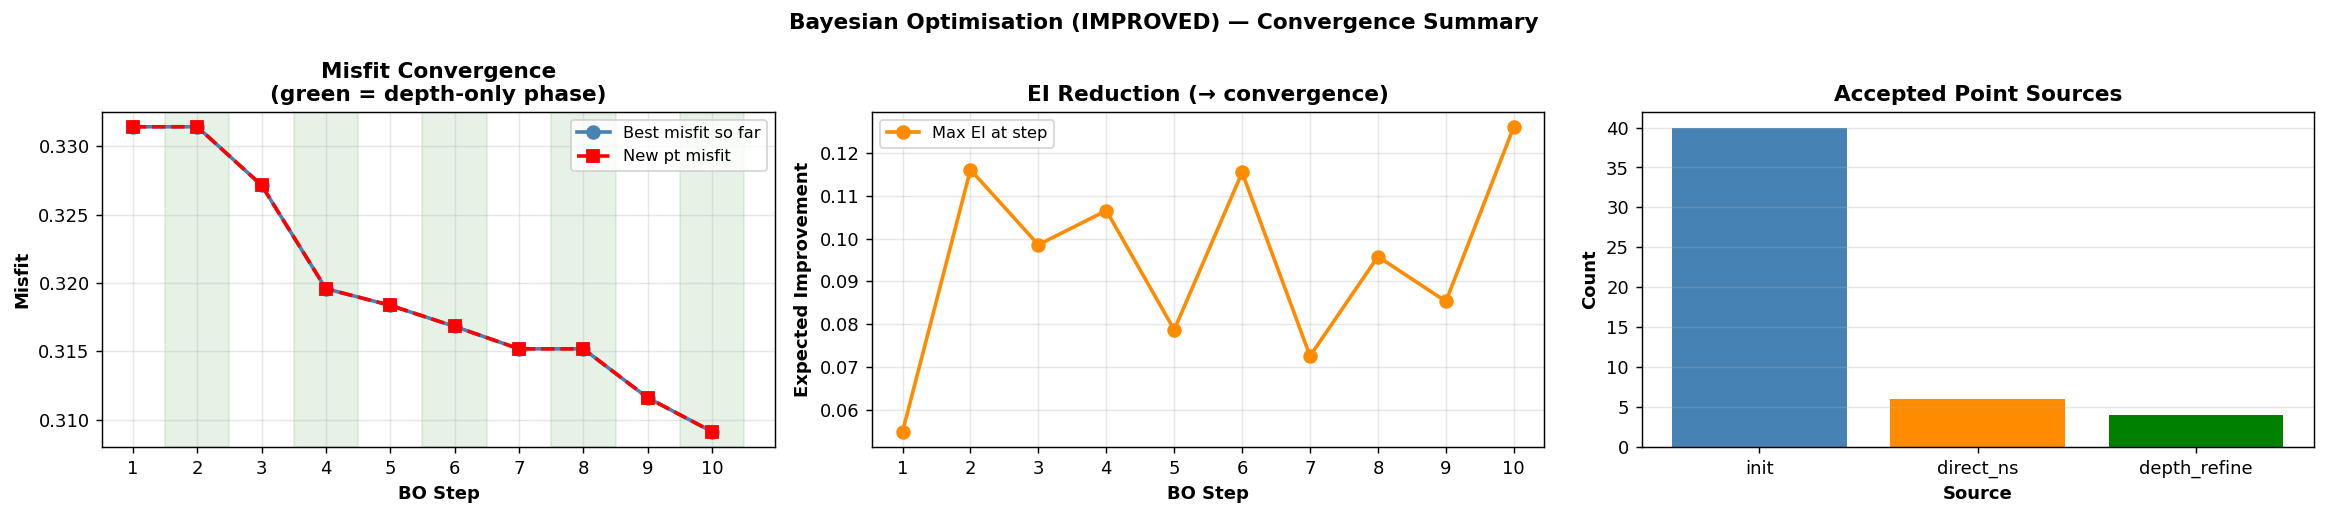

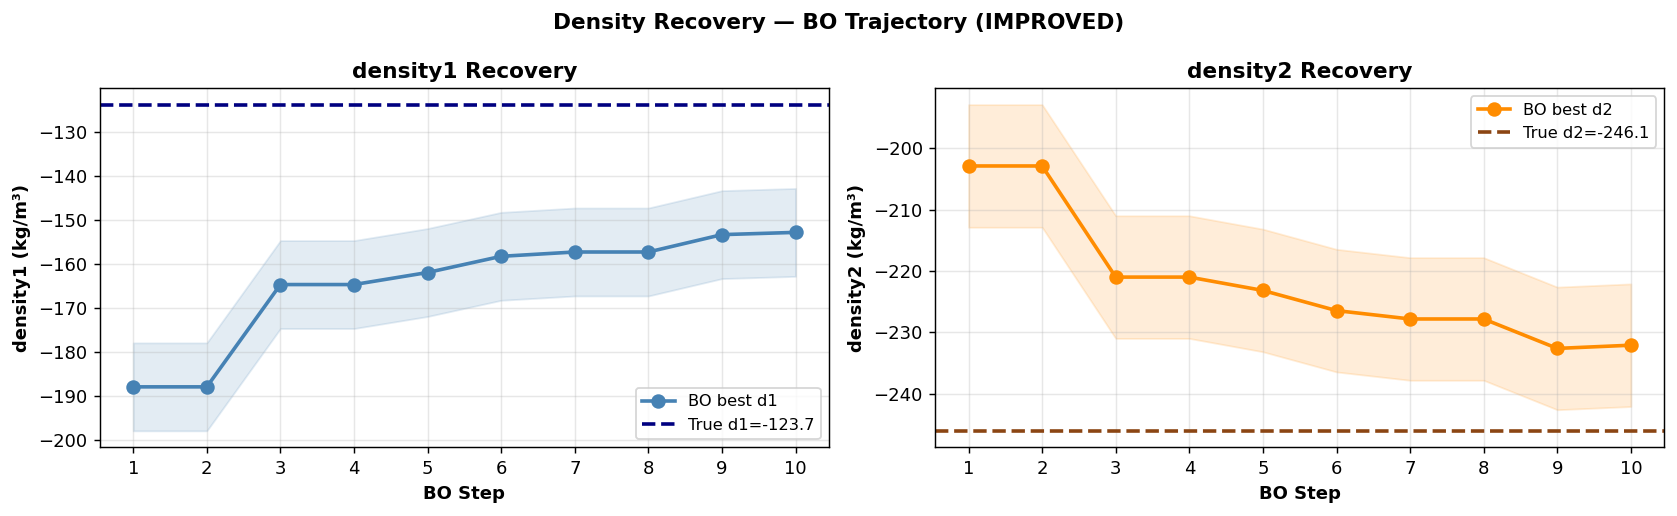

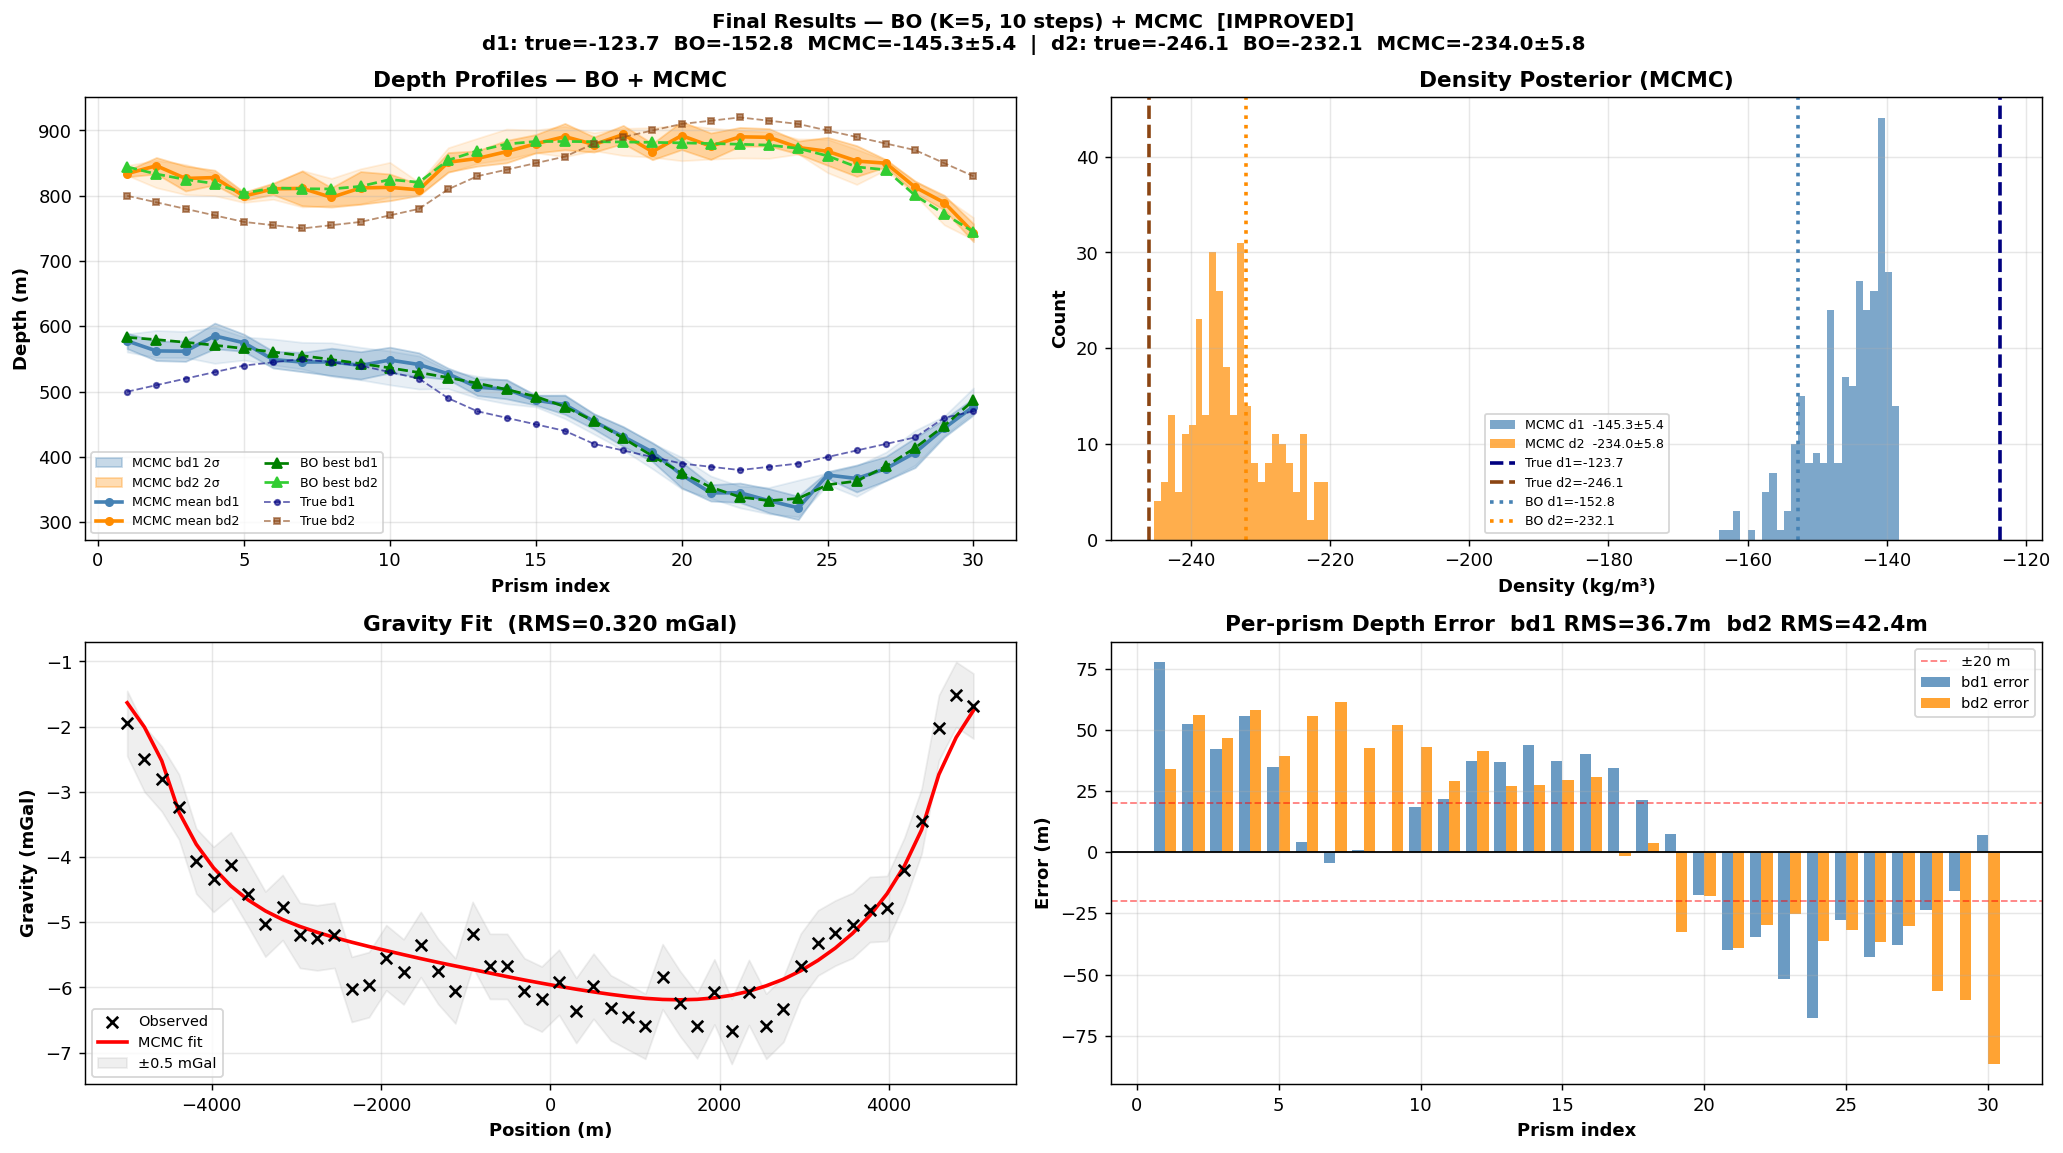


Bayesian Optimisation (IMPROVED) complete.
Total evaluations: 50  (init=40 + BO=10)

  FINAL SUMMARY
  K (ctrl pts)    : 5  (was 3)
  LAMBDA_REG      : 0.001  (was 0.005)
  NUM_SAMPLES     : 300  (was 30)
  Best BO misfit  : 0.3091
  Density recovery:
    density1 : true=-123.75  BO=-152.80  MCMC=-145.35±5.36
    density2 : true=-246.06  BO=-232.10  MCMC=-234.03±5.84
  MCMC depth RMS  : bd1=36.68m  bd2=42.38m
  Gravity residual: 0.3205 mGal
  Forward cache   : 278 entries


In [ ]:
# =============================================================================
#  CHOOSE WHICH STEP TO EXTRACT  ← change this number
# =============================================================================
EXTRACT_STEP = 8   # set to None to use the overall best across all steps

if EXTRACT_STEP is not None:
    # Pull the best state recorded at the chosen step
    snap     = history["best_state"][EXTRACT_STEP - 1]
    best_c1f = snap["c1"].copy()
    best_c2f = snap["c2"].copy()
    best_d1f = snap["d1"]
    best_d2f = snap["d2"]
    best_bd1 = snap["bd1"].copy()
    best_bd2 = snap["bd2"].copy()
    best_mf  = snap["misfit"]
    print(f"  Extracting result from BO step {EXTRACT_STEP}")
else:
    # Original behaviour: use the global best
    bsf      = int(np.argmin(mf_hist))
    best_c1f = np.asarray(c1_hist[bsf])
    best_c2f = np.asarray(c2_hist[bsf])
    best_d1f = float(d1_hist[bsf])
    best_d2f = float(d2_hist[bsf])
    best_bd1 = bd1_hist[bsf]
    best_bd2 = bd2_hist[bsf]
    best_mf  = mf_hist[bsf]
    print(f"  Using global best (step {bsf - N_INIT + 1})")

print(f"  Best BO misfit : {best_mf:.4f}  d1={best_d1f:.2f}  d2={best_d2f:.2f}")
# =============================================================================
#  FIX 5: DEDICATED POST-BO DEPTH-ONLY REFINEMENT PASS
#  After BO converges density, do a thorough depth-only optimisation
#  with many restarts before handing off to MCMC.
# =============================================================================
print("\n" + "="*60)
print("  POST-BO DEPTH-ONLY REFINEMENT PASS")
print("="*60)

bsf      = int(np.argmin(mf_hist))
best_c1f = np.asarray(c1_hist[bsf])
best_c2f = np.asarray(c2_hist[bsf])
best_d1f = float(d1_hist[bsf])
best_d2f = float(d2_hist[bsf])
best_bd1 = bd1_hist[bsf]
best_bd2 = bd2_hist[bsf]
best_mf  = mf_hist[bsf]

print(f"  Best BO misfit : {best_mf:.4f}  d1={best_d1f:.2f}  d2={best_d2f:.2f}")

# Generate diverse depth starts for the refinement pass
ref_c1, ref_c2, _, _, _ = lhs_sample_depth_only(
    20, best_d1f, best_d2f, seed=999)
# Prepend the BO best
ref_c1 = np.vstack([best_c1f.reshape(1,-1), ref_c1])
ref_c2 = np.vstack([best_c2f.reshape(1,-1), ref_c2])

print(f"  Running depth-only refinement with {len(ref_c1)} restarts...")
do_c1_final, do_c2_final, do_mf_final = local_optimise_depth_only(
    ref_c1, ref_c2,
    best_d1f, best_d2f,
    observed_gravity, PARAMS,
    n_restarts=len(ref_c1), maxiter=500)

if do_c1_final is not None and do_mf_final < best_mf:
    print(f"  ✓ Depth refinement: {best_mf:.4f} → {do_mf_final:.4f}")
    best_c1f = do_c1_final
    best_c2f = do_c2_final
    best_bd1 = profile_from_controls(best_c1f, bd1_lo, bd1_hi)
    best_bd2 = profile_from_controls(best_c2f, bd2_lo, bd2_hi)
    best_mf  = do_mf_final
else:
    print(f"  No improvement from depth refinement pass.")

# Joint polish of best depth + density
print("  Final joint L-BFGS-B polish...")
pol_c1, pol_c2, pol_d1, pol_d2, pol_mf = local_optimise(
    [best_c1f], [best_c2f], [best_d1f], [best_d2f],
    observed_gravity, PARAMS)

if pol_c1 is not None and pol_mf < best_mf:
    print(f"  ✓ Joint polish: {best_mf:.4f} → {pol_mf:.4f}  "
          f"d1={pol_d1:.2f}  d2={pol_d2:.2f}")
    best_c1f, best_c2f = pol_c1, pol_c2
    best_d1f, best_d2f = pol_d1, pol_d2
    best_bd1 = profile_from_controls(pol_c1, bd1_lo, bd1_hi)
    best_bd2 = profile_from_controls(pol_c2, bd2_lo, bd2_hi)
    best_mf  = pol_mf

# =============================================================================
#  SHRINK PRIORS
# =============================================================================
hw1 = np.maximum((bd1_hi-bd1_lo)*SHRINK_FACTOR/2, 5.0)
hw2 = np.maximum((bd2_hi-bd2_lo)*SHRINK_FACTOR/2, 5.0)
new_bd1_lo = np.maximum(best_bd1-hw1, bd1_lo)
new_bd1_hi = np.minimum(best_bd1+hw1, bd1_hi)
new_bd2_lo = np.maximum(best_bd2-hw2, bd2_lo)
new_bd2_hi = np.minimum(best_bd2+hw2, bd2_hi)
new_bd2_lo = np.maximum(new_bd2_lo, new_bd1_hi+5.0)
new_bd2_hi = np.maximum(new_bd2_hi, new_bd2_lo+5.0)

D1_HW     = (D1_HI-D1_LO)*SHRINK_FACTOR/2
D2_HW     = (D2_HI-D2_LO)*SHRINK_FACTOR/2
new_d1_lo = max(best_d1f-D1_HW, D1_LO)
new_d1_hi = min(best_d1f+D1_HW, D1_HI)
new_d2_lo = max(best_d2f-D2_HW, D2_LO)
new_d2_hi = min(best_d2f+D2_HW, D2_HI)

print(f"\n  Updated density priors:")
print(f"    d1: [{new_d1_lo:.1f}, {new_d1_hi:.1f}]")
print(f"    d2: [{new_d2_lo:.1f}, {new_d2_hi:.1f}]")

# =============================================================================
#  FIX 6: FINAL MCMC  (more samples: 300 warmup=500)
# =============================================================================
print("\n" + "="*60)
print(f"  FINAL MCMC (SA — gradient-free)")
print(f"  warmup={NUM_WARMUP}  samples={NUM_SAMPLES}")
print(f"  density1 prior : [{new_d1_lo:.1f}, {new_d1_hi:.1f}]")
print(f"  density2 prior : [{new_d2_lo:.1f}, {new_d2_hi:.1f}]")
print("="*60)

def _np_fwd_mcmc(bd1_np, bd2_np, d1, d2):
    p = copy.deepcopy(PARAMS)
    p["density1"] = float(d1);  p["density2"] = float(d2)
    for i in range(n):
        p[f"B_D1_{i+1}"] = float(bd1_np[i])
        p[f"B_D2_{i+1}"] = float(bd2_np[i])
    return np.array([Bayes_Inf(np.asarray(xi).item(), p)
                     for xi in X], dtype=np.float64)

def jax_forward_sa(bd1_vec, bd2_vec, d1, d2):
    return jax.pure_callback(
        lambda args: _np_fwd_mcmc(args[0], args[1], args[2], args[3]),
        jax.ShapeDtypeStruct((len(X),), jnp.float64),
        (bd1_vec, bd2_vec, d1, d2),
        vmap_method="sequential")

def inversion_model_sa():
    d1 = numpyro.sample("density1", dist.Uniform(new_d1_lo, new_d1_hi))
    d2 = numpyro.sample("density2", dist.Uniform(new_d2_lo, new_d2_hi))
    b1 = jnp.stack([numpyro.sample(f"B_D1_{i+1}",
                    dist.Uniform(float(new_bd1_lo[i]), float(new_bd1_hi[i])))
                    for i in range(n)])
    b2 = jnp.stack([numpyro.sample(f"B_D2_{i+1}",
                    dist.Uniform(float(new_bd2_lo[i]), float(new_bd2_hi[i])))
                    for i in range(n)])
    g  = jax_forward_sa(b1, b2, d1, d2)
    numpyro.sample("obs", dist.Normal(g, NOISE_SIGMA),
                   obs=jnp.array(observed_gravity, dtype=jnp.float64))

t_mcmc = time.time()
mcmc_final = MCMC(
    SA(inversion_model_sa, adapt_state_size=NUM_SAMPLES),
    num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES,
    num_chains=1, progress_bar=True)
mcmc_final.run(jax.random.PRNGKey(SEED))
print(f"  MCMC time: {(time.time()-t_mcmc)/60:.1f} min")
mcmc_final.print_summary()

samples  = mcmc_final.get_samples()
pb1m = np.array([samples[f"B_D1_{i+1}"].mean() for i in range(n)])
pb1s = np.array([samples[f"B_D1_{i+1}"].std()  for i in range(n)])
pb2m = np.array([samples[f"B_D2_{i+1}"].mean() for i in range(n)])
pb2s = np.array([samples[f"B_D2_{i+1}"].std()  for i in range(n)])
d1_samp = np.array(samples["density1"])
d2_samp = np.array(samples["density2"])

# =============================================================================
#  SUMMARY FIGURE 1 — Convergence
# =============================================================================
fig_summ, axes_s = plt.subplots(1, 2, figsize=(18, 4), dpi=130)
fig_summ.suptitle("Bayesian Optimisation (IMPROVED) — Convergence Summary",
                  fontsize=12, fontweight='bold')
steps_arr = np.array(history["step"])

axes_s[0].plot(steps_arr, history["best_misfit"], 'o-',
               color='steelblue', lw=2, ms=7, label='Best misfit so far')

# shade alternating phases
for s, ph in enumerate(history["phase"]):
    if ph == "DEPTH-ONLY":
        axes_s[0].axvspan(s+0.5, s+1.5, alpha=0.10, color='green')
axes_s[0].set_xlabel("BO Step", fontweight='bold')
axes_s[0].set_ylabel("Misfit", fontweight='bold')
axes_s[0].set_title("Misfit Convergence",
                     fontweight='bold')
axes_s[0].set_xticks(steps_arr)
axes_s[0].legend(fontsize=9); axes_s[0].grid(True, alpha=0.3)

axes_s[1].plot(steps_arr, history["ei_max"], 'o-',
               color='darkorange', lw=2, ms=7, label='Max EI at step')
axes_s[1].set_xlabel("BO Step", fontweight='bold')
axes_s[1].set_ylabel("Expected Improvement", fontweight='bold')
axes_s[1].set_title("EI Reduction (→ convergence)", fontweight='bold')
axes_s[1].set_xticks(steps_arr)
axes_s[1].legend(fontsize=9); axes_s[1].grid(True, alpha=0.3)



plt.tight_layout()
#plt.savefig("bo_convergence_summary.png", dpi=130, bbox_inches='tight')
plt.show()

# =============================================================================
#  SUMMARY FIGURE 2 — Density trajectory
# =============================================================================
fig_den, axes_d = plt.subplots(1, 2, figsize=(13, 4), dpi=130)
fig_den.suptitle("Density Recovery — BO Trajectory (IMPROVED)",
                 fontsize=12, fontweight='bold')
d1_arr = np.array(history["d1_trace"])
d2_arr = np.array(history["d2_trace"])

axes_d[0].plot(steps_arr, d1_arr, 'o-', color='steelblue', lw=2, ms=7,
               label='BO best d1')
axes_d[0].axhline(float(den1[0]), color='navy', ls='--', lw=2,
                  label=f'True density1={float(den1[0])}')
axes_d[0].fill_between(steps_arr, d1_arr-10, d1_arr+10,
                        color='steelblue', alpha=0.15)
axes_d[0].set_xlabel("BO Step", fontweight='bold')
axes_d[0].set_ylabel("density1 (kg/m³)", fontweight='bold')
axes_d[0].set_title("density1 Recovery", fontweight='bold')
axes_d[0].set_xticks(steps_arr)
axes_d[0].legend(fontsize=9); axes_d[0].grid(True, alpha=0.3)

axes_d[1].plot(steps_arr, d2_arr, 'o-', color='darkorange', lw=2, ms=7,
               label='BO best d2')
axes_d[1].axhline(float(den2[0]), color='saddlebrown', ls='--', lw=2,
                  label=f'True density2={float(den2[0])}')
axes_d[1].fill_between(steps_arr, d2_arr-10, d2_arr+10,
                        color='darkorange', alpha=0.15)
axes_d[1].set_xlabel("BO Step", fontweight='bold')
axes_d[1].set_ylabel("density2 (kg/m³)", fontweight='bold')
axes_d[1].set_title("density2 Recovery", fontweight='bold')
axes_d[1].set_xticks(steps_arr)
axes_d[1].legend(fontsize=9); axes_d[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("density_recovery.png", dpi=130, bbox_inches='tight')
plt.show()

# =============================================================================
#  SUMMARY FIGURE 3 — Final results
# =============================================================================
e1   = pb1m - true_bd1_full
e2   = pb2m - true_bd2_full
ce1f = best_c1f - true_bd1_at_ctrl
ce2f = best_c2f - true_bd2_at_ctrl

pp = copy.deepcopy(PARAMS)
pp["density1"] = float(d1_samp.mean())
pp["density2"] = float(d2_samp.mean())
for i in range(n):
    pp[f"B_D1_{i+1}"] = float(pb1m[i])
    pp[f"B_D2_{i+1}"] = float(pb2m[i])
gp_fit  = np.array([Bayes_Inf(np.asarray(xi).item(), pp) for xi in X])
res_rms = float(np.sqrt(np.mean((observed_gravity - gp_fit)**2)))

fig_res, axes_r = plt.subplots(2, 2, figsize=(16, 9), dpi=130)
fig_res.suptitle(
    f"Final Results — BO (K={K}, {N_BO_STEPS} steps) + MCMC (Extracted step at {EXTRACT_STEP})",
    fontsize=12, fontweight='bold')

ax = axes_r[0, 0]
ax.fill_between(prism_idx, new_bd1_lo, new_bd1_hi, alpha=0.12, color='steelblue')
ax.fill_between(prism_idx, new_bd2_lo, new_bd2_hi, alpha=0.12, color='darkorange')
ax.fill_between(prism_idx, pb1m-2*pb1s, pb1m+2*pb1s,
                alpha=0.30, color='steelblue', label='MCMC bd1 2σ')
ax.fill_between(prism_idx, pb2m-2*pb2s, pb2m+2*pb2s,
                alpha=0.30, color='darkorange', label='MCMC bd2 2σ')
ax.plot(prism_idx, pb1m, 'o-', color='steelblue', lw=2, ms=4, label='MCMC mean bd1')
ax.plot(prism_idx, pb2m, 'o-', color='darkorange', lw=2, ms=4, label='MCMC mean bd2')
ax.plot(prism_idx, best_bd1, '^--', color='green',     lw=1.5, ms=5, label='BO best bd1')
ax.plot(prism_idx, best_bd2, '^--', color='limegreen', lw=1.5, ms=5, label='BO best bd2')
ax.plot(prism_idx, bd1, 'o--', color='navy',
        ms=3, lw=1, alpha=0.6, label='True bd1')
ax.plot(prism_idx, bd2, 's--', color='saddlebrown',
        ms=3, lw=1, alpha=0.6, label='True bd2')
ax.set_xlabel("Prism index", fontweight='bold')
ax.set_ylabel("Depth (m)", fontweight='bold')
ax.set_title("Depth Profiles — BO + MCMC", fontweight='bold')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

ax = axes_r[0, 1]
ax.hist(d1_samp, bins=25, color='steelblue', alpha=0.7,
        label=f"MCMC density1  {d1_samp.mean():.1f}±{d1_samp.std():.1f}")
ax.hist(d2_samp, bins=25, color='darkorange', alpha=0.7,
        label=f"MCMC density2  {d2_samp.mean():.1f}±{d2_samp.std():.1f}")
ax.axvline(float(den1[0]), color='navy',        lw=2, ls='--',
           label=f"True density1={float(den1[0])}")
ax.axvline(float(den2[0]), color='saddlebrown', lw=2, ls='--',
           label=f"True density2={float(den2[0])}")
ax.axvline(best_d1f, color='steelblue', lw=2, ls=':',
           label=f"BO density1={best_d1f:.1f}")
ax.axvline(best_d2f, color='darkorange', lw=2, ls=':',
           label=f"BO density2={best_d2f:.1f}")
ax.set_xlabel("Density (kg/m³)", fontweight='bold')
ax.set_ylabel("Count", fontweight='bold')
ax.set_title("Density Posterior (MCMC)", fontweight='bold')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes_r[1, 0]
X_plot = np.asarray(X).flatten()          # ensure 1-D for fill_between
ax.scatter(X_plot, observed_gravity, marker='x', s=40, c='black',
           zorder=4, label='Observed')
ax.plot(X_plot, gp_fit, 'r-', lw=2, label='MCMC fit')
ax.fill_between(X_plot, observed_gravity-NOISE_SIGMA, observed_gravity+NOISE_SIGMA,
                alpha=0.12, color='gray', label=f'±{NOISE_SIGMA} mGal')
ax.set_xlabel("Position (m)", fontweight='bold')
ax.set_ylabel("Gravity (mGal)", fontweight='bold')
ax.set_title(f"Gravity Fit  (RMS={res_rms:.3f} mGal)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes_r[1, 1]
ax.bar(prism_idx-0.2, e1, width=0.4, color='steelblue',
       alpha=0.8, label='bd1 error')
ax.bar(prism_idx+0.2, e2, width=0.4, color='darkorange',
       alpha=0.8, label='bd2 error')
ax.axhline(0,   color='k',   lw=1)
ax.axhline( 20, color='red', ls='--', lw=1, alpha=0.5)
ax.axhline(-20, color='red', ls='--', lw=1, alpha=0.5, label='±20 m')
ax.set_xlabel("Prism index", fontweight='bold')
ax.set_ylabel("Error (m)", fontweight='bold')
ax.set_title(f"Per-prism Depth Error  "
             f"bd1 RMS={np.sqrt(np.mean(e1**2)):.1f}m  "
             f"bd2 RMS={np.sqrt(np.mean(e2**2)):.1f}m",
             fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bo_final_results.png", dpi=130, bbox_inches='tight')
plt.show()

# =============================================================================
#  FINAL PRINT SUMMARY
# =============================================================================
print(f"\nBayesian Optimisation (IMPROVED) complete.")
print(f"Total evaluations: {len(mf_hist)}  (init={N_INIT} + BO={N_BO_STEPS})")
print(f"\n{'='*60}")
print(f"  FINAL SUMMARY")
print(f"{'='*60}")
print(f"  K (ctrl pts)    : {K}  (was 3)")
print(f"  LAMBDA_REG      : {LAMBDA_REG}  (was 0.005)")
print(f"  NUM_SAMPLES     : {NUM_SAMPLES}  (was 30)")
print(f"  Best BO misfit  : {best_mf:.4f}")
print(f"  Density recovery:")
print(f"    density1 : true={PARAMS['density1']:.2f}  BO={best_d1f:.2f}  "
      f"MCMC={d1_samp.mean():.2f}±{d1_samp.std():.2f}")
print(f"    density2 : true={PARAMS['density2']:.2f}  BO={best_d2f:.2f}  "
      f"MCMC={d2_samp.mean():.2f}±{d2_samp.std():.2f}")
print(f"  MCMC depth RMS  : bd1={np.sqrt(np.mean(e1**2)):.2f}m  "
      f"bd2={np.sqrt(np.mean(e2**2)):.2f}m")
print(f"  Gravity residual: {res_rms:.4f} mGal")
print(f"  Forward cache   : {len(_fwd_cache)} entries")
print(f"{'='*60}")